In [1]:
#===============================
# Imports
#===============================
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import glob
from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle, Patch
from matplotlib.lines import Line2D
import matplotlib.gridspec as gridspec
import datetime
import matplotlib.colors as colors
import matplotlib as mpl
from pytz import utc
from matplotlib.lines import Line2D
import scipy
from scipy.spatial import cKDTree
from dask.distributed import wait
from distributed import Client, LocalCluster
import sys
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.io.img_tiles as cimgt
import shapely.geometry as sgeom
import matplotlib.patheffects as path_effects
import dask
import pandas as pd
from matplotlib.colors import ListedColormap, BoundaryNorm
import logging
import copy
import hashlib
import palettable
import pickle
import scipy.stats

import warnings
warnings.filterwarnings("ignore")


/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


In [2]:
def truncate_colormap(cmap, minval=0.0, maxval=1.0, n=256):
    """ Truncate colormap.
    """
    new_cmap = mpl.colors.LinearSegmentedColormap.from_list(
        'trunc({n},{a:.2f},{b:.2f})'.format(n=cmap.name, a=minval, b=maxval),
        cmap(np.linspace(minval, maxval, n)))
    return new_cmap

# ========================================
# Read in obs pickle files
# ========================================

In [3]:
read_path = '../processing_code/part_1/'
file_name_500m = 'old_2/obs_500m_cell_track_reflectivity_disdrometer.p'
file_name_3km = 'obs_3km_cell_track_reflectivity_disdrometer.p'
# Load the dictionary
with open(read_path+file_name_500m, 'rb') as f:
    obs_dict_500m = pickle.load(f)
with open(read_path+file_name_3km, 'rb') as f:
    obs_dict_3km = pickle.load(f)   

# ========================================
# ------------------WRF------------------- 
# ========================================

# Read in WRF pickle file

In [4]:
read_path = './'
file_name = 'wrf_3km_cell_track_reflectivity_disdrometer.p'
# Load the dictionary
with open(read_path+file_name, 'rb') as f:
    wrf_dict = pickle.load(f)

In [5]:
obs_dict_3km['num_cells']

181

In [6]:
len(wrf_dict['amf_lwc'])

238

In [7]:
plt.rcParams['text.usetex'] = True

# Joint KDEs of VDIS, CSAPR-3km, and WRF

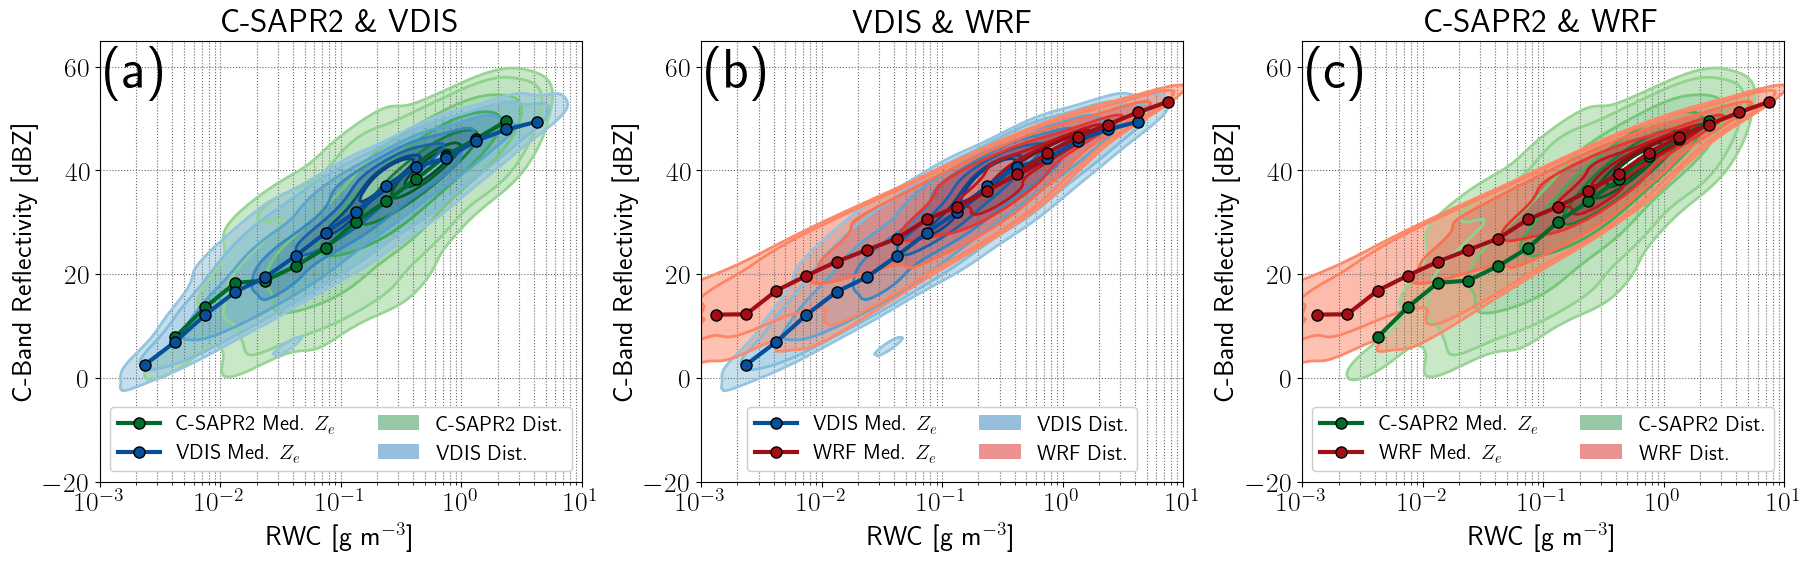

done


In [8]:
def find_density_levels(density_grid, probability_levels):
    """
    Calculates the density contour levels that enclose given probability masses.

    Args:
        density_grid (np.ndarray): The 2D array of density values from the KDE.
        probability_levels (list or np.ndarray): A list of probabilities
            for which to find the corresponding density level (e.g., [0.50, 0.95]).

    Returns:
        np.ndarray: An array of density values. Plotting contours at these
                    levels will enclose the specified probability mass.
    """
    # Flatten and sort the density grid in descending order
    sorted_densities = np.sort(density_grid.ravel())[::-1]
    
    # Calculate the cumulative sum of densities
    cumulative_mass = np.cumsum(sorted_densities)
    
    # Normalize the cumulative sum to be a CDF (0 to 1)
    total_mass = cumulative_mass[-1]
    if total_mass == 0:
        return np.array([]) # Avoid division by zero for empty grids
    normalized_cdf = cumulative_mass / total_mass
    
    # Find the density levels for each probability
    # np.searchsorted finds the index where the probability level would be inserted
    # to maintain order. We then use this index to find the corresponding density.
    indices = np.searchsorted(normalized_cdf, probability_levels)
    
    # Clip indices to be within the bounds of the sorted_densities array
    indices = np.clip(indices, 0, len(sorted_densities) - 1)
    
    levels = sorted_densities[indices]
    
    # It's better for plotting if levels are sorted ascending
    return np.sort(levels)

def plot_kde_and_mean_probability(ax, x_data, y_data, x_bins, 
                                  # NEW: Pass in the grid limits
                                  grid_xlim_log, grid_ylim, color, label, 
                                  probability_levels=[0.50, 0.90, 0.99], 
                                  min_samples_threshold=10,
                                  stat_to_plot='mean'):
    """
    Calculates and plots a joint KDE and a binned mean line, ensuring the mean
    is only calculated for bins with a minimum number of samples.
    
    Args:
        min_samples_threshold (int): The minimum number of data points required in
            a bin to calculate and plot the mean for that bin.
    """
    # --- KDE Plotting (no changes here) ---
    x_log = np.log10(x_data)
    y_data_clean = y_data.copy()

    xmin, xmax = np.min(x_log), np.max(x_log)
    ymin, ymax = np.min(y_data_clean), np.max(y_data_clean)
    
    #xx, yy = np.mgrid[xmin:xmax:150j, ymin:ymax:150j] 
    xx, yy = np.mgrid[grid_xlim_log[0]:grid_xlim_log[1]:200j, 
                      grid_ylim[0]:grid_ylim[1]:200j]
    
    positions = np.vstack([xx.ravel(), yy.ravel()])
    values = np.vstack([x_log, y_data_clean])
    
    if values.shape[1] < 2:
        print(f"Skipping KDE for {label}: not enough data points.")
        return

    kernel = scipy.stats.gaussian_kde(values)
    f = np.reshape(kernel(positions).T, xx.shape)
    
    levels = find_density_levels(f, probability_levels)
    if len(levels) == 0:
        print(f"Skipping contour plot for {label}: could not determine levels.")
    else:
        cmap = plt.get_cmap(color)
        new_cmap = truncate_colormap(cmap, 0.4, 1.0)
        ax.contourf(10**xx, yy, f, cmap=new_cmap, levels=levels, alpha=0.5)
        all_levels = np.append(levels, f.max())
        #ax.contour(10**xx, yy, f, cmap=new_cmap, levels=all_levels, linewidths=0.8)
        ax.contour(10**xx, yy, f, cmap=new_cmap, levels=all_levels, linewidths=2)

    # --- Binned Mean Calculation with Thresholding ---
    x_mid_bins = 10.**(0.5 * (np.log10(x_bins[:-1]) + np.log10(x_bins[1:])))
    mean_y = []
    median_y = []
    
    for i in range(len(x_bins) - 1):
        mask = (x_data >= x_bins[i]) & (x_data < x_bins[i+1])
        num_samples_in_bin = np.sum(mask)

        # Check if the bin meets the minimum sample count threshold
        if num_samples_in_bin < min_samples_threshold:
            mean_y.append(np.nan)
            median_y.append(np.nan)
            continue
        
        # This calculation only proceeds for valid bins
        y_linear = 10**(y_data_clean[mask] / 10.)
        mean_y_linear = np.mean(y_linear)
        mean_y.append(10. * np.log10(mean_y_linear))
        median_y.append(np.median(y_data_clean[mask]))

    if stat_to_plot == 'mean':
        ax.plot(x_mid_bins, mean_y, lw=3, marker='o', c=new_cmap(0.8), label=f'{label} Mean $Z_e$', markersize=8, markeredgecolor='k',zorder=10)
    elif stat_to_plot == 'median':
        ax.plot(x_mid_bins, median_y, lw=3, marker='o', c=new_cmap(0.8), label=f'{label} Med. $Z_e$', markersize=8, markeredgecolor='k',zorder=10)


# You need the helper function defined above: find_density_levels
# You need the plotting function defined above: plot_kde_and_mean_probability
# You need your truncate_colormap function.

# --- Setup Figure ---
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)
Fontsize = 20
axlist = [ax1, ax2, ax3]
RWC_LIMS = [1e-3, 1e1]
DBZ_LIMS = [-20, 65]
for ax in axlist:
    ax.grid(which='both', ls='dotted', c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_xlabel(r'RWC [g m$^{-3}$]', fontsize=Fontsize)
    ax.set_ylabel(r'C-Band Reflectivity [dBZ]', fontsize=Fontsize)
    ax.set_xscale('log')
    #ax.set_xlim(1e-4, 1e1)
    #ax.set_ylim(-20, 65)
    # Set the final view limits for each axis
    ax.set_xlim(RWC_LIMS)
    ax.set_ylim(DBZ_LIMS)
# --- Define Bins ---
exp = np.arange(-3, 1.25, 0.25)
lwc_bins = 10.**exp


# === DEFINE THE SINGLE, WIDE GRID & PLOT LIMITS ===
# The GRID must be wide enough for the widest contour.
# The PLOT limits can be the same or slightly tighter.
# NOTE: The X-limits for the grid must be in log10 space!
GRID_XLIM_LOG = (np.log10(1e-5), np.log10(5e1)) # Generously wide in log space
GRID_YLIM = (-40, 80)                         # Generously wide

# Define the probability levels you want to visualize
# This will draw contours enclosing 50%, 90%, and 99% of the data.
prob_levels = [0.05, 0.1, 0.25, 0.50, 0.75, 0.90, 0.95]

# --- Plot Data ---
MIN_SAMPLES=5

#stat = 'mean'
stat = 'median'

# Plot CSAPR
plot_kde_and_mean_probability(ax1, obs_dict_3km['all_cell_lwc'], obs_dict_3km['all_cell_dbz'], lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Greens', 'C-SAPR2', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)
plot_kde_and_mean_probability(ax3, obs_dict_3km['all_cell_lwc'], obs_dict_3km['all_cell_dbz'], lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Greens', 'C-SAPR2', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)

# Plot VDIS
plot_kde_and_mean_probability(ax1, obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['lwc'], obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['reflectivity_factor_cband20c'], lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Blues', 'VDIS', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)
plot_kde_and_mean_probability(ax2, obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['lwc'], obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['reflectivity_factor_cband20c'], lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Blues', 'VDIS', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)

# Plot WRF
plot_kde_and_mean_probability(ax2, wrf_dict['all_cell_lwc'], wrf_dict['all_cell_dbz'], lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Reds', 'WRF', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)
plot_kde_and_mean_probability(ax3, wrf_dict['all_cell_lwc'], wrf_dict['all_cell_dbz'], lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Reds', 'WRF', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)


# --- Titles and Legends ---
ax1.set_title(r'C-SAPR2 \& VDIS', fontsize=Fontsize*1.2)
ax2.set_title(r'VDIS \& WRF', fontsize=Fontsize*1.2)
ax3.set_title(r'C-SAPR2 \& WRF', fontsize=Fontsize*1.2)

# Create a single, clear legend
handles, labels = [], []
for ax in [ax1, ax2, ax3]:
    h, l = ax.get_legend_handles_labels()
    for i, label in enumerate(l):
        if label not in labels:
            labels.append(label)
            handles.append(h[i])

# Add patches for the KDE areas

# Get the base colormaps
cmap_csapr = plt.get_cmap('Greens')
cmap_vdis = plt.get_cmap('Blues')
cmap_wrf = plt.get_cmap('Reds')

# Create the truncated colormaps, exactly as done in the plotting function
new_cmap_csapr = truncate_colormap(cmap_csapr, 0.4, 1.0)
new_cmap_vdis = truncate_colormap(cmap_vdis, 0.4, 1.0)
new_cmap_wrf = truncate_colormap(cmap_wrf, 0.4, 1.0)

if True:
    # Plot (a)
    handles_ax1, labels_ax1 = ax1.get_legend_handles_labels()
    patches_ax1 = [
        Patch(facecolor=new_cmap_csapr(0.5), label=r'CSAPR Dist.', alpha=0.5),
        Patch(facecolor=new_cmap_vdis(0.5), label=r'VDIS Dist.', alpha=0.5),
    ]
    handles_ax1.extend(patches_ax1)
    ax1.legend(handles=handles_ax1 + patches_ax1, 
               labels=labels_ax1 + ['C-SAPR2 Dist.', 'VDIS Dist.'], 
               loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=2, 
               fontsize=Fontsize*0.75, framealpha=1)
    # Plot (b)
    handles_ax2, labels_ax2 = ax2.get_legend_handles_labels()
    patches_ax2 = [
        Patch(facecolor=new_cmap_vdis(0.5), label=r'VDIS Dist.', alpha=0.5),
        Patch(facecolor=new_cmap_wrf(0.5), label=r'WRF Dist.', alpha=0.5),
    ]
    handles_ax2.extend(patches_ax2)
    ax2.legend(handles=handles_ax2 + patches_ax2, 
               labels=labels_ax2 + ['VDIS Dist.', 'WRF Dist.'], 
               loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=2, 
               fontsize=Fontsize*0.75, framealpha=1)
    # Plot (c)
    handles_ax3, labels_ax3 = ax3.get_legend_handles_labels()
    patches_ax3 = [
        Patch(facecolor=new_cmap_csapr(0.5), label=r'CSAPR Dist.', alpha=0.5),
        Patch(facecolor=new_cmap_wrf(0.5), label=r'WRF Dist.', alpha=0.5),
    ]
    handles_ax3.extend(patches_ax3)
    ax3.legend(handles=handles_ax3 + patches_ax3, 
               labels=labels_ax3 + ['C-SAPR2 Dist.', 'WRF Dist.'], 
               loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=2, 
               fontsize=Fontsize*0.75, framealpha=1)



if False:
    patches = [
        Patch(facecolor=new_cmap_csapr(0.5), label=r'C-SAPR2 Dist.', alpha=0.5),
        Patch(facecolor=new_cmap_vdis(0.5), label=r'VDIS Dist.', alpha=0.5),
        Patch(facecolor=new_cmap_wrf(0.5), label=r'WRF Dist.', alpha=0.5)
    ]
    handles.extend(patches)
    labels.extend([r'C-SAPR2 Dist.', r'VDIS Dist.', r'WRF Dist.'])
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.185, 0.1), ncol=2, fontsize=Fontsize*0.9,framealpha=1)


labs = ['(a)','(b)','(c)']
for i,ax in enumerate(axlist):
    ax.text(0.01,0.99,labs[i],transform=ax.transAxes,ha='left',va='top',fontsize=Fontsize*2.)


save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
outfile = save_path+f'fig_vdis_csapr_wrf_rwc_dbz_{stat}.png'
#plt.savefig(outfile,dpi=300)
plt.show()
plt.close()
print('done')

In [9]:
def find_density_levels(density_grid, probability_levels):
    """
    Calculates the density contour levels that enclose given probability masses.

    Args:
        density_grid (np.ndarray): The 2D array of density values from the KDE.
        probability_levels (list or np.ndarray): A list of probabilities
            for which to find the corresponding density level (e.g., [0.50, 0.95]).

    Returns:
        np.ndarray: An array of density values. Plotting contours at these
                    levels will enclose the specified probability mass.
    """
    # Flatten and sort the density grid in descending order
    sorted_densities = np.sort(density_grid.ravel())[::-1]
    
    # Calculate the cumulative sum of densities
    cumulative_mass = np.cumsum(sorted_densities)
    
    # Normalize the cumulative sum to be a CDF (0 to 1)
    total_mass = cumulative_mass[-1]
    if total_mass == 0:
        return np.array([]) # Avoid division by zero for empty grids
    normalized_cdf = cumulative_mass / total_mass
    
    # Find the density levels for each probability
    # np.searchsorted finds the index where the probability level would be inserted
    # to maintain order. We then use this index to find the corresponding density.
    indices = np.searchsorted(normalized_cdf, probability_levels)
    
    # Clip indices to be within the bounds of the sorted_densities array
    indices = np.clip(indices, 0, len(sorted_densities) - 1)
    
    levels = sorted_densities[indices]
    
    # It's better for plotting if levels are sorted ascending
    return np.sort(levels)



def plot_kde_and_mean_probability(ax, x_data, y_data, x_bins, 
                                  # NEW: Pass in the grid limits
                                  grid_xlim_log, grid_ylim, color, label, 
                                  probability_levels=[0.50, 0.90, 0.99], 
                                  min_samples_threshold=10,
                                  stat_to_plot='mean'):
    """
    Calculates and plots a joint KDE and a binned mean line, ensuring the mean
    is only calculated for bins with a minimum number of samples.
    
    Args:
        min_samples_threshold (int): The minimum number of data points required in
            a bin to calculate and plot the mean for that bin.
    """
    # --- KDE Plotting (no changes here) ---
    x_log = np.log10(x_data)
    y_data_clean = y_data.copy()

    xmin, xmax = np.min(x_log), np.max(x_log)
    ymin, ymax = np.min(y_data_clean), np.max(y_data_clean)
    
    #xx, yy = np.mgrid[xmin:xmax:150j, ymin:ymax:150j] 
    xx, yy = np.mgrid[grid_xlim_log[0]:grid_xlim_log[1]:200j, 
                      grid_ylim[0]:grid_ylim[1]:200j]
    
    positions = np.vstack([xx.ravel(), yy.ravel()])
    values = np.vstack([x_log, y_data_clean])
    
    if values.shape[1] < 2:
        print(f"Skipping KDE for {label}: not enough data points.")
        return

    kernel = scipy.stats.gaussian_kde(values)
    f = np.reshape(kernel(positions).T, xx.shape)
    
    levels = find_density_levels(f, probability_levels)
    if len(levels) == 0:
        print(f"Skipping contour plot for {label}: could not determine levels.")
    else:
        cmap = plt.get_cmap(color)
        new_cmap = truncate_colormap(cmap, 0.4, 1.0)
        ax.contourf(10**xx, yy, f, cmap=new_cmap, levels=levels, alpha=0.5)
        all_levels = np.append(levels, f.max())
        #ax.contour(10**xx, yy, f, cmap=new_cmap, levels=all_levels, linewidths=0.8)
        ax.contour(10**xx, yy, f, cmap=new_cmap, levels=all_levels, linewidths=2)

    # --- Binned Mean Calculation with Thresholding ---
    x_mid_bins = 10.**(0.5 * (np.log10(x_bins[:-1]) + np.log10(x_bins[1:])))
    mean_y = []
    median_y = []
    
    for i in range(len(x_bins) - 1):
        mask = (x_data >= x_bins[i]) & (x_data < x_bins[i+1])
        num_samples_in_bin = np.sum(mask)

        # Check if the bin meets the minimum sample count threshold
        if num_samples_in_bin < min_samples_threshold:
            mean_y.append(np.nan)
            median_y.append(np.nan)
            continue
        
        # This calculation only proceeds for valid bins
        y_linear = 10**(y_data_clean[mask] / 10.)
        mean_y_linear = np.mean(y_linear)
        mean_y.append(10. * np.log10(mean_y_linear))
        median_y.append(np.median(y_data_clean[mask]))

    if stat_to_plot == 'mean':
        ax.plot(x_mid_bins, mean_y, lw=3, marker='o', c=new_cmap(0.8), label=f'{label} Mean $Z_e$', markersize=8, markeredgecolor='k',zorder=10)
    elif stat_to_plot == 'median':
        ax.plot(x_mid_bins, median_y, lw=3, marker='o', c=new_cmap(0.8), label=f'{label} Med. $Z_e$', markersize=8, markeredgecolor='k',zorder=10)


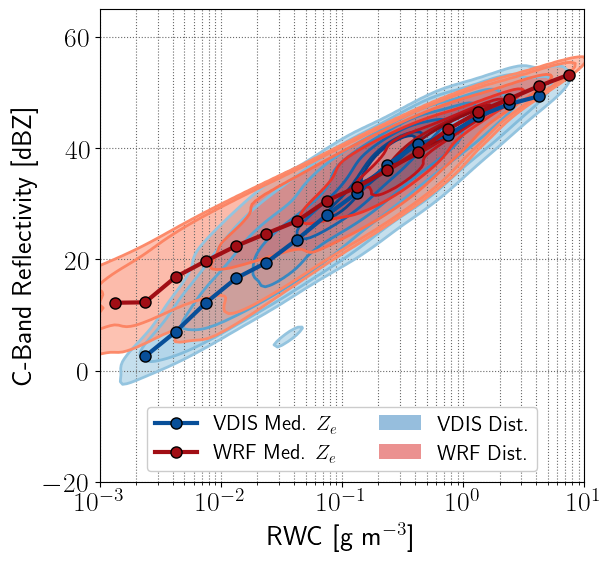

In [10]:
# --- Setup Figure ---
fig, ax1 = plt.subplots(1, 1, figsize=(6, 5.5), constrained_layout=True)
Fontsize = 20
axlist = [ax1]
RWC_LIMS = [1e-3, 1e1]
DBZ_LIMS = [-20, 65]
for ax in axlist:
    ax.grid(which='both', ls='dotted', c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_xlabel(r'RWC [g m$^{-3}$]', fontsize=Fontsize)
    ax.set_ylabel(r'C-Band Reflectivity [dBZ]', fontsize=Fontsize)
    ax.set_xscale('log')
    #ax.set_xlim(1e-4, 1e1)
    #ax.set_ylim(-20, 65)
    # Set the final view limits for each axis
    ax.set_xlim(RWC_LIMS)
    ax.set_ylim(DBZ_LIMS)
# --- Define Bins ---
exp = np.arange(-3, 1.25, 0.25)
lwc_bins = 10.**exp


# === DEFINE THE SINGLE, WIDE GRID & PLOT LIMITS ===
# The GRID must be wide enough for the widest contour.
# The PLOT limits can be the same or slightly tighter.
# NOTE: The X-limits for the grid must be in log10 space!
GRID_XLIM_LOG = (np.log10(1e-5), np.log10(5e1)) # Generously wide in log space
GRID_YLIM = (-40, 80)                         # Generously wide

# Define the probability levels you want to visualize
# This will draw contours enclosing 50%, 90%, and 99% of the data.
prob_levels = [0.05, 0.1, 0.25, 0.50, 0.75, 0.90, 0.95]

# --- Plot Data ---
MIN_SAMPLES=5

#stat = 'mean'
stat = 'median'

# Plot VDIS
plot_kde_and_mean_probability(ax1, obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['lwc'], obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['reflectivity_factor_cband20c'], lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Blues', 'VDIS', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)
# Plot WRF
plot_kde_and_mean_probability(ax1, wrf_dict['all_cell_lwc'], wrf_dict['all_cell_dbz'], lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Reds', 'WRF', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)


# --- Titles and Legends ---
#ax1.set_title(r'VDIS \& WRF', fontsize=Fontsize*1.2)

# Create a single, clear legend
handles, labels = [], []
for ax in [ax1]:
    h, l = ax.get_legend_handles_labels()
    for i, label in enumerate(l):
        if label not in labels:
            labels.append(label)
            handles.append(h[i])

# Add patches for the KDE areas

# Get the base colormaps
cmap_vdis = plt.get_cmap('Blues')
cmap_wrf = plt.get_cmap('Reds')

# Create the truncated colormaps, exactly as done in the plotting function
new_cmap_vdis = truncate_colormap(cmap_vdis, 0.4, 1.0)
new_cmap_wrf = truncate_colormap(cmap_wrf, 0.4, 1.0)


handles_ax1, labels_ax1 = ax1.get_legend_handles_labels()
patches_ax1 = [
    Patch(facecolor=new_cmap_vdis(0.5), label=r'VDIS Dist.', alpha=0.5),
    Patch(facecolor=new_cmap_wrf(0.5), label=r'WRF Dist.', alpha=0.5),
]
handles_ax1.extend(patches_ax1)
ax1.legend(handles=handles_ax1 + patches_ax1, 
           labels=labels_ax1 + ['VDIS Dist.', 'WRF Dist.'], 
           #labels=labels_ax1 + ['VDIS Dist.'], 
           loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=2, 
           fontsize=Fontsize*0.75, framealpha=1)

# Joint KDE of RWC vs. dBZ for VDIS & LD

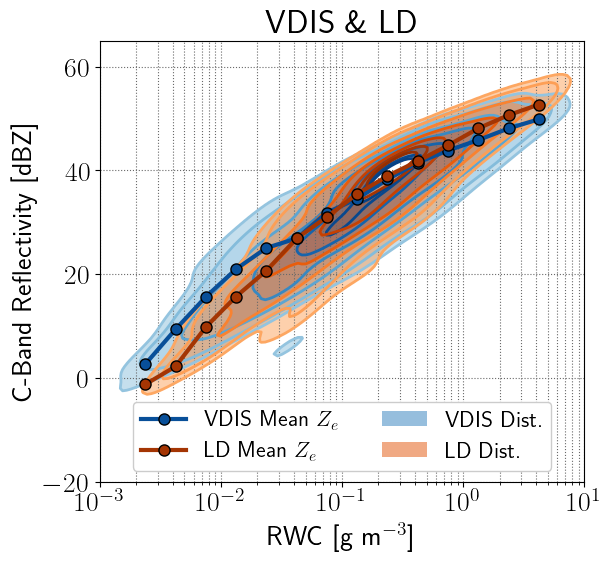

done


In [11]:
def find_density_levels(density_grid, probability_levels):
    """
    Calculates the density contour levels that enclose given probability masses.

    Args:
        density_grid (np.ndarray): The 2D array of density values from the KDE.
        probability_levels (list or np.ndarray): A list of probabilities
            for which to find the corresponding density level (e.g., [0.50, 0.95]).

    Returns:
        np.ndarray: An array of density values. Plotting contours at these
                    levels will enclose the specified probability mass.
    """
    # Flatten and sort the density grid in descending order
    sorted_densities = np.sort(density_grid.ravel())[::-1]
    
    # Calculate the cumulative sum of densities
    cumulative_mass = np.cumsum(sorted_densities)
    
    # Normalize the cumulative sum to be a CDF (0 to 1)
    total_mass = cumulative_mass[-1]
    if total_mass == 0:
        return np.array([]) # Avoid division by zero for empty grids
    normalized_cdf = cumulative_mass / total_mass
    
    # Find the density levels for each probability
    # np.searchsorted finds the index where the probability level would be inserted
    # to maintain order. We then use this index to find the corresponding density.
    indices = np.searchsorted(normalized_cdf, probability_levels)
    
    # Clip indices to be within the bounds of the sorted_densities array
    indices = np.clip(indices, 0, len(sorted_densities) - 1)
    
    levels = sorted_densities[indices]
    
    # It's better for plotting if levels are sorted ascending
    return np.sort(levels)

def plot_kde_and_mean_probability(ax, x_data, y_data, x_bins, 
                                  # NEW: Pass in the grid limits
                                  grid_xlim_log, grid_ylim, color, label, 
                                  probability_levels=[0.50, 0.90, 0.99], 
                                  min_samples_threshold=10,
                                  stat_to_plot='mean'):
    """
    Calculates and plots a joint KDE and a binned mean line, ensuring the mean
    is only calculated for bins with a minimum number of samples.
    
    Args:
        min_samples_threshold (int): The minimum number of data points required in
            a bin to calculate and plot the mean for that bin.
    """
    # --- KDE Plotting (no changes here) ---
    x_log = np.log10(x_data)
    y_data_clean = y_data.copy()

    xmin, xmax = np.min(x_log), np.max(x_log)
    ymin, ymax = np.min(y_data_clean), np.max(y_data_clean)
    
    #xx, yy = np.mgrid[xmin:xmax:150j, ymin:ymax:150j] 
    xx, yy = np.mgrid[grid_xlim_log[0]:grid_xlim_log[1]:200j, 
                      grid_ylim[0]:grid_ylim[1]:200j]
    
    positions = np.vstack([xx.ravel(), yy.ravel()])
    values = np.vstack([x_log, y_data_clean])
    
    if values.shape[1] < 2:
        print(f"Skipping KDE for {label}: not enough data points.")
        return

    kernel = scipy.stats.gaussian_kde(values)
    f = np.reshape(kernel(positions).T, xx.shape)
    
    levels = find_density_levels(f, probability_levels)
    if len(levels) == 0:
        print(f"Skipping contour plot for {label}: could not determine levels.")
    else:
        cmap = plt.get_cmap(color)
        new_cmap = truncate_colormap(cmap, 0.4, 1.0)
        ax.contourf(10**xx, yy, f, cmap=new_cmap, levels=levels, alpha=0.5)
        all_levels = np.append(levels, f.max())
        #ax.contour(10**xx, yy, f, cmap=new_cmap, levels=all_levels, linewidths=0.8)
        ax.contour(10**xx, yy, f, cmap=new_cmap, levels=all_levels, linewidths=2)

    # --- Binned Mean Calculation with Thresholding ---
    x_mid_bins = 10.**(0.5 * (np.log10(x_bins[:-1]) + np.log10(x_bins[1:])))
    mean_y = []
    median_y = []
    
    for i in range(len(x_bins) - 1):
        mask = (x_data >= x_bins[i]) & (x_data < x_bins[i+1])
        num_samples_in_bin = np.sum(mask)

        # Check if the bin meets the minimum sample count threshold
        if num_samples_in_bin < min_samples_threshold:
            mean_y.append(np.nan)
            median_y.append(np.nan)
            continue
        
        # This calculation only proceeds for valid bins
        y_linear = 10**(y_data_clean[mask] / 10.)
        mean_y_linear = np.mean(y_linear)
        mean_y.append(10. * np.log10(mean_y_linear))
        median_y.append(np.median(y_data_clean[mask]))

    if stat_to_plot == 'mean':
        ax.plot(x_mid_bins, mean_y, lw=3, marker='o', c=new_cmap(0.8), label=f'{label} Mean $Z_e$', markersize=8, markeredgecolor='k',zorder=10)
    elif stat_to_plot == 'median':
        ax.plot(x_mid_bins, median_y, lw=3, marker='o', c=new_cmap(0.8), label=f'{label} Med. $Z_e$', markersize=8, markeredgecolor='k',zorder=10)


# You need the helper function defined above: find_density_levels
# You need the plotting function defined above: plot_kde_and_mean_probability
# You need your truncate_colormap function.

# --- Setup Figure ---
fig, ax1 = plt.subplots(1, 1, figsize=(6, 5.5), constrained_layout=True)
Fontsize = 20
axlist = [ax1,]
RWC_LIMS = [1e-3, 1e1]
DBZ_LIMS = [-20, 65]
for ax in axlist:
    ax.grid(which='both', ls='dotted', c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_xlabel(r'RWC [g m$^{-3}$]', fontsize=Fontsize)
    ax.set_ylabel(r'C-Band Reflectivity [dBZ]', fontsize=Fontsize)
    ax.set_xscale('log')
    #ax.set_xlim(1e-4, 1e1)
    #ax.set_ylim(-20, 65)
    # Set the final view limits for each axis
    ax.set_xlim(RWC_LIMS)
    ax.set_ylim(DBZ_LIMS)
# --- Define Bins ---
exp = np.arange(-3, 1.25, 0.25)
lwc_bins = 10.**exp


# === DEFINE THE SINGLE, WIDE GRID & PLOT LIMITS ===
# The GRID must be wide enough for the widest contour.
# The PLOT limits can be the same or slightly tighter.
# NOTE: The X-limits for the grid must be in log10 space!
GRID_XLIM_LOG = (np.log10(1e-5), np.log10(5e1)) # Generously wide in log space
GRID_YLIM = (-40, 80)                         # Generously wide

# Define the probability levels you want to visualize
# This will draw contours enclosing 50%, 90%, and 99% of the data.
prob_levels = [0.05, 0.1, 0.25, 0.50, 0.75, 0.90, 0.95]

# --- Plot Data ---
MIN_SAMPLES=5

stat = 'mean'
#stat = 'median'

# Plot VDIS
plot_kde_and_mean_probability(ax1, obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['lwc'], obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['reflectivity_factor_cband20c'], lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Blues', 'VDIS', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)
plot_kde_and_mean_probability(ax1, obs_dict_3km['ld_dict']['ld_matched_expand_dict']['lwc'], obs_dict_3km['ld_dict']['ld_matched_expand_dict']['reflectivity_factor_cband20c'], lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Oranges', 'LD', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)


# --- Titles and Legends ---
ax1.set_title(r'VDIS \& LD', fontsize=Fontsize*1.2)

# Create a single, clear legend
handles, labels = [], []
for ax in [ax1]:
    h, l = ax.get_legend_handles_labels()
    for i, label in enumerate(l):
        if label not in labels:
            labels.append(label)
            handles.append(h[i])

# Add patches for the KDE areas

# Get the base colormaps
cmap_vdis = plt.get_cmap('Blues')
cmap_ld = plt.get_cmap('Oranges')

# Create the truncated colormaps, exactly as done in the plotting function
new_cmap_vdis = truncate_colormap(cmap_vdis, 0.4, 1.0)
new_cmap_ld = truncate_colormap(cmap_ld, 0.4, 1.0)

# Plot (a)
handles_ax1, labels_ax1 = ax1.get_legend_handles_labels()
patches_ax1 = [
    Patch(facecolor=new_cmap_vdis(0.5), label=r'VDIS Dist.', alpha=0.5),
    Patch(facecolor=new_cmap_ld(0.5), label=r'LD Dist.', alpha=0.5),
]
handles_ax1.extend(patches_ax1)
ax1.legend(handles=handles_ax1 + patches_ax1, 
           labels=labels_ax1 + ['VDIS Dist.', 'LD Dist.'], 
           loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=2, 
           fontsize=Fontsize*0.8, framealpha=1)



save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
outfile = save_path+f'fig_vdis_ld_rwc_dbz_{stat}.png'
#plt.savefig(outfile,dpi=300)
plt.show()
plt.close()
print('done')

# Joint KDES of VDIS, LD, CSAPR-3km, and CSAPR-500m

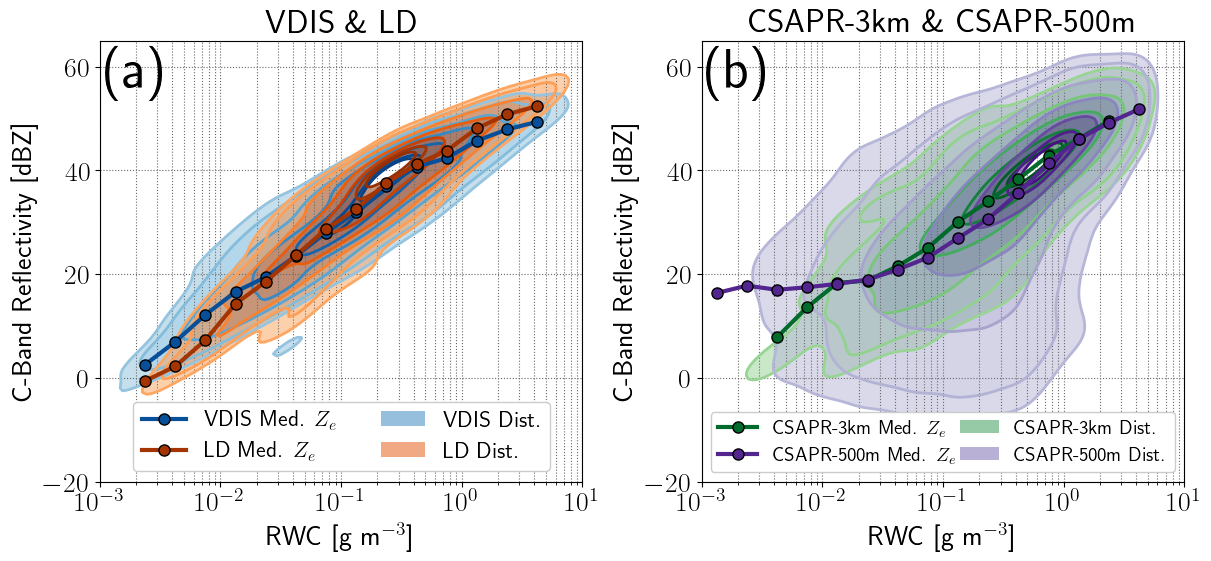

done


In [12]:
def find_density_levels(density_grid, probability_levels):
    """
    Calculates the density contour levels that enclose given probability masses.

    Args:
        density_grid (np.ndarray): The 2D array of density values from the KDE.
        probability_levels (list or np.ndarray): A list of probabilities
            for which to find the corresponding density level (e.g., [0.50, 0.95]).

    Returns:
        np.ndarray: An array of density values. Plotting contours at these
                    levels will enclose the specified probability mass.
    """
    # Flatten and sort the density grid in descending order
    sorted_densities = np.sort(density_grid.ravel())[::-1]
    
    # Calculate the cumulative sum of densities
    cumulative_mass = np.cumsum(sorted_densities)
    
    # Normalize the cumulative sum to be a CDF (0 to 1)
    total_mass = cumulative_mass[-1]
    if total_mass == 0:
        return np.array([]) # Avoid division by zero for empty grids
    normalized_cdf = cumulative_mass / total_mass
    
    # Find the density levels for each probability
    # np.searchsorted finds the index where the probability level would be inserted
    # to maintain order. We then use this index to find the corresponding density.
    indices = np.searchsorted(normalized_cdf, probability_levels)
    
    # Clip indices to be within the bounds of the sorted_densities array
    indices = np.clip(indices, 0, len(sorted_densities) - 1)
    
    levels = sorted_densities[indices]
    
    # It's better for plotting if levels are sorted ascending
    return np.sort(levels)

def plot_kde_and_mean_probability(ax, x_data, y_data, x_bins, 
                                  # NEW: Pass in the grid limits
                                  grid_xlim_log, grid_ylim, color, label, 
                                  probability_levels=[0.50, 0.90, 0.99], 
                                  min_samples_threshold=10,
                                  stat_to_plot='mean'):
    """
    Calculates and plots a joint KDE and a binned mean line, ensuring the mean
    is only calculated for bins with a minimum number of samples.
    
    Args:
        min_samples_threshold (int): The minimum number of data points required in
            a bin to calculate and plot the mean for that bin.
    """
    # --- KDE Plotting (no changes here) ---
    x_log = np.log10(x_data)
    y_data_clean = y_data.copy()

    xmin, xmax = np.min(x_log), np.max(x_log)
    ymin, ymax = np.min(y_data_clean), np.max(y_data_clean)
    
    #xx, yy = np.mgrid[xmin:xmax:150j, ymin:ymax:150j] 
    xx, yy = np.mgrid[grid_xlim_log[0]:grid_xlim_log[1]:200j, 
                      grid_ylim[0]:grid_ylim[1]:200j]
    
    positions = np.vstack([xx.ravel(), yy.ravel()])
    values = np.vstack([x_log, y_data_clean])
    
    if values.shape[1] < 2:
        print(f"Skipping KDE for {label}: not enough data points.")
        return

    kernel = scipy.stats.gaussian_kde(values)
    f = np.reshape(kernel(positions).T, xx.shape)
    
    levels = find_density_levels(f, probability_levels)
    if len(levels) == 0:
        print(f"Skipping contour plot for {label}: could not determine levels.")
    else:
        cmap = plt.get_cmap(color)
        new_cmap = truncate_colormap(cmap, 0.4, 1.0)
        ax.contourf(10**xx, yy, f, cmap=new_cmap, levels=levels, alpha=0.5)
        all_levels = np.append(levels, f.max())
        #ax.contour(10**xx, yy, f, cmap=new_cmap, levels=all_levels, linewidths=0.8)
        ax.contour(10**xx, yy, f, cmap=new_cmap, levels=all_levels, linewidths=2)

    # --- Binned Mean Calculation with Thresholding ---
    x_mid_bins = 10.**(0.5 * (np.log10(x_bins[:-1]) + np.log10(x_bins[1:])))
    mean_y = []
    median_y = []
    
    for i in range(len(x_bins) - 1):
        mask = (x_data >= x_bins[i]) & (x_data < x_bins[i+1])
        num_samples_in_bin = np.sum(mask)

        # Check if the bin meets the minimum sample count threshold
        if num_samples_in_bin < min_samples_threshold:
            mean_y.append(np.nan)
            median_y.append(np.nan)
            continue
        
        # This calculation only proceeds for valid bins
        y_linear = 10**(y_data_clean[mask] / 10.)
        mean_y_linear = np.mean(y_linear)
        median_y_linear = np.median(y_linear)
        mean_y.append(10. * np.log10(mean_y_linear))
        #median_y.append(10. * np.log10(median_y_linear))
        median_y.append(np.median(y_data_clean[mask]))

    if stat_to_plot == 'mean':
        ax.plot(x_mid_bins, mean_y, lw=3, marker='o', c=new_cmap(0.8), label=f'{label} Mean $Z_e$', markersize=8, markeredgecolor='k',zorder=10)
    elif stat_to_plot == 'median':
        ax.plot(x_mid_bins, median_y, lw=3, marker='o', c=new_cmap(0.8), label=f'{label} Med. $Z_e$', markersize=8, markeredgecolor='k',zorder=10)

# You need the helper function defined above: find_density_levels
# You need the plotting function defined above: plot_kde_and_mean_probability
# You need your truncate_colormap function.

# --- Setup Figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5), constrained_layout=True)
Fontsize = 20
axlist = [ax1,ax2]
RWC_LIMS = [1e-3, 1e1]
DBZ_LIMS = [-20, 65]
for ax in axlist:
    ax.grid(which='both', ls='dotted', c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_xlabel(r'RWC [g m$^{-3}$]', fontsize=Fontsize)
    ax.set_ylabel(r'C-Band Reflectivity [dBZ]', fontsize=Fontsize)
    ax.set_xscale('log')
    #ax.set_xlim(1e-4, 1e1)
    #ax.set_ylim(-20, 65)
    # Set the final view limits for each axis
    ax.set_xlim(RWC_LIMS)
    ax.set_ylim(DBZ_LIMS)
# --- Define Bins ---
exp = np.arange(-3, 1.25, 0.25)
lwc_bins = 10.**exp


# === DEFINE THE SINGLE, WIDE GRID & PLOT LIMITS ===
# The GRID must be wide enough for the widest contour.
# The PLOT limits can be the same or slightly tighter.
# NOTE: The X-limits for the grid must be in log10 space!
GRID_XLIM_LOG = (np.log10(1e-5), np.log10(5e1)) # Generously wide in log space
GRID_YLIM = (-40, 80)                         # Generously wide

# Define the probability levels you want to visualize
# This will draw contours enclosing 50%, 90%, and 99% of the data.
prob_levels = [0.05, 0.1, 0.25, 0.50, 0.75, 0.90, 0.95]

# --- Plot Data ---
MIN_SAMPLES=5
# Plot CSAPR

#stat = 'mean'
stat = 'median'

# Plot VDIS
plot_kde_and_mean_probability(ax1, obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['lwc'], obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['reflectivity_factor_cband20c'], \
                              lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Blues', 'VDIS', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)
plot_kde_and_mean_probability(ax1, obs_dict_3km['ld_dict']['ld_matched_expand_dict']['lwc'], obs_dict_3km['ld_dict']['ld_matched_expand_dict']['reflectivity_factor_cband20c'], \
                              lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Oranges', 'LD', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)

plot_kde_and_mean_probability(ax2, obs_dict_3km['all_cell_lwc'], obs_dict_3km['all_cell_dbz'], \
                              lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Greens', 'CSAPR-3km', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)
plot_kde_and_mean_probability(ax2, obs_dict_500m['all_cell_lwc'], obs_dict_500m['all_cell_dbz'], \
                              lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Purples', 'CSAPR-500m', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)

# --- Titles and Legends ---
ax1.set_title(r'VDIS \& LD', fontsize=Fontsize*1.2)
ax2.set_title(r'CSAPR-3km \& CSAPR-500m', fontsize=Fontsize*1.2)

# Create a single, clear legend
handles, labels = [], []
for ax in [ax1,ax2]:
    h, l = ax.get_legend_handles_labels()
    for i, label in enumerate(l):
        if label not in labels:
            labels.append(label)
            handles.append(h[i])

# Add patches for the KDE areas

# Get the base colormaps
cmap_csapr = plt.get_cmap('Greens')
cmap_csapr_500m = plt.get_cmap('Purples')
cmap_vdis = plt.get_cmap('Blues')
cmap_ld = plt.get_cmap('Oranges')

# Create the truncated colormaps, exactly as done in the plotting function
new_cmap_csapr = truncate_colormap(cmap_csapr, 0.4, 1.0)
new_cmap_csapr_500m = truncate_colormap(cmap_csapr_500m, 0.4, 1.0)
new_cmap_vdis = truncate_colormap(cmap_vdis, 0.4, 1.0)
new_cmap_ld = truncate_colormap(cmap_ld, 0.4, 1.0)

# Plot (a)
handles_ax1, labels_ax1 = ax1.get_legend_handles_labels()
patches_ax1 = [
    Patch(facecolor=new_cmap_vdis(0.5), label=r'VDIS Dist.', alpha=0.5),
    Patch(facecolor=new_cmap_ld(0.5), label=r'LD Dist.', alpha=0.5),
]
handles_ax1.extend(patches_ax1)
ax1.legend(handles=handles_ax1 + patches_ax1, 
           labels=labels_ax1 + ['VDIS Dist.', 'LD Dist.'], 
           loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=2, 
           fontsize=Fontsize*0.8, framealpha=1)
# Plot (b)
handles_ax2, labels_ax2 = ax2.get_legend_handles_labels()
patches_ax2 = [
    Patch(facecolor=new_cmap_csapr(0.5), label=r'CSAPR-3km Dist.', alpha=0.5),
    Patch(facecolor=new_cmap_csapr_500m(0.5), label=r'CSAPR-500m Dist.', alpha=0.5),
]
handles_ax2.extend(patches_ax2)
ax2.legend(handles=handles_ax2 + patches_ax2, 
           labels=labels_ax2 + ['CSAPR-3km Dist.', 'CSAPR-500m Dist.'], 
           loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=2, 
           fontsize=Fontsize*0.7, framealpha=1,columnspacing=0.2)

labs = ['(a)','(b)']
for i,ax in enumerate(axlist):
    ax.text(0.01,0.99,labs[i],transform=ax.transAxes,ha='left',va='top',fontsize=Fontsize*2.)


save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
outfile = save_path+f'fig_vdis_ld_csapr_rwc_dbz_{stat}.png'
#plt.savefig(outfile,dpi=300)
plt.show()
plt.close()
print('done')

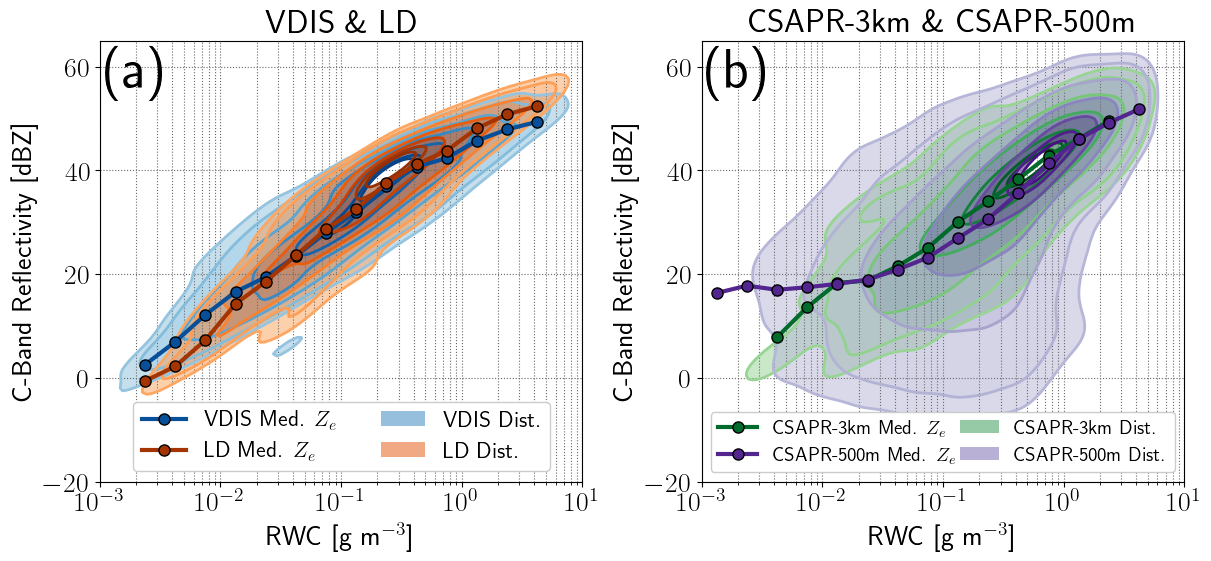

done


In [13]:
def find_density_levels(density_grid, probability_levels):
    """
    Calculates the density contour levels that enclose given probability masses.

    Args:
        density_grid (np.ndarray): The 2D array of density values from the KDE.
        probability_levels (list or np.ndarray): A list of probabilities
            for which to find the corresponding density level (e.g., [0.50, 0.95]).

    Returns:
        np.ndarray: An array of density values. Plotting contours at these
                    levels will enclose the specified probability mass.
    """
    # Flatten and sort the density grid in descending order
    sorted_densities = np.sort(density_grid.ravel())[::-1]
    
    # Calculate the cumulative sum of densities
    cumulative_mass = np.cumsum(sorted_densities)
    
    # Normalize the cumulative sum to be a CDF (0 to 1)
    total_mass = cumulative_mass[-1]
    if total_mass == 0:
        return np.array([]) # Avoid division by zero for empty grids
    normalized_cdf = cumulative_mass / total_mass
    
    # Find the density levels for each probability
    # np.searchsorted finds the index where the probability level would be inserted
    # to maintain order. We then use this index to find the corresponding density.
    indices = np.searchsorted(normalized_cdf, probability_levels)
    
    # Clip indices to be within the bounds of the sorted_densities array
    indices = np.clip(indices, 0, len(sorted_densities) - 1)
    
    levels = sorted_densities[indices]
    
    # It's better for plotting if levels are sorted ascending
    return np.sort(levels)

def plot_kde_and_mean_probability(ax, x_data, y_data, x_bins, 
                                  # NEW: Pass in the grid limits
                                  grid_xlim_log, grid_ylim, color, label, 
                                  probability_levels=[0.50, 0.90, 0.99], 
                                  min_samples_threshold=10,
                                  stat_to_plot='mean'):
    """
    Calculates and plots a joint KDE and a binned mean line, ensuring the mean
    is only calculated for bins with a minimum number of samples.
    
    Args:
        min_samples_threshold (int): The minimum number of data points required in
            a bin to calculate and plot the mean for that bin.
    """
    # --- KDE Plotting (no changes here) ---
    x_log = np.log10(x_data)
    y_data_clean = y_data.copy()

    xmin, xmax = np.min(x_log), np.max(x_log)
    ymin, ymax = np.min(y_data_clean), np.max(y_data_clean)
    
    #xx, yy = np.mgrid[xmin:xmax:150j, ymin:ymax:150j] 
    xx, yy = np.mgrid[grid_xlim_log[0]:grid_xlim_log[1]:200j, 
                      grid_ylim[0]:grid_ylim[1]:200j]
    
    positions = np.vstack([xx.ravel(), yy.ravel()])
    values = np.vstack([x_log, y_data_clean])
    
    if values.shape[1] < 2:
        print(f"Skipping KDE for {label}: not enough data points.")
        return

    kernel = scipy.stats.gaussian_kde(values)
    f = np.reshape(kernel(positions).T, xx.shape)
    
    levels = find_density_levels(f, probability_levels)
    if len(levels) == 0:
        print(f"Skipping contour plot for {label}: could not determine levels.")
    else:
        cmap = plt.get_cmap(color)
        new_cmap = truncate_colormap(cmap, 0.4, 1.0)
        ax.contourf(10**xx, yy, f, cmap=new_cmap, levels=levels, alpha=0.5)
        all_levels = np.append(levels, f.max())
        #ax.contour(10**xx, yy, f, cmap=new_cmap, levels=all_levels, linewidths=0.8)
        ax.contour(10**xx, yy, f, cmap=new_cmap, levels=all_levels, linewidths=2)

    # --- Binned Mean Calculation with Thresholding ---
    x_mid_bins = 10.**(0.5 * (np.log10(x_bins[:-1]) + np.log10(x_bins[1:])))
    mean_y = []
    median_y = []
    
    for i in range(len(x_bins) - 1):
        mask = (x_data >= x_bins[i]) & (x_data < x_bins[i+1])
        num_samples_in_bin = np.sum(mask)

        # Check if the bin meets the minimum sample count threshold
        if num_samples_in_bin < min_samples_threshold:
            mean_y.append(np.nan)
            median_y.append(np.nan)
            continue
        
        # This calculation only proceeds for valid bins
        y_linear = 10**(y_data_clean[mask] / 10.)
        mean_y_linear = np.mean(y_linear)
        median_y_linear = np.median(y_linear)
        mean_y.append(10. * np.log10(mean_y_linear))
        #median_y.append(10. * np.log10(median_y_linear))
        median_y.append(np.median(y_data_clean[mask]))

    if stat_to_plot == 'mean':
        ax.plot(x_mid_bins, mean_y, lw=3, marker='o', c=new_cmap(0.8), label=f'{label} Mean $Z_e$', markersize=8, markeredgecolor='k',zorder=10)
    elif stat_to_plot == 'median':
        ax.plot(x_mid_bins, median_y, lw=3, marker='o', c=new_cmap(0.8), label=f'{label} Med. $Z_e$', markersize=8, markeredgecolor='k',zorder=10)

# You need the helper function defined above: find_density_levels
# You need the plotting function defined above: plot_kde_and_mean_probability
# You need your truncate_colormap function.

# --- Setup Figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5), constrained_layout=True)
Fontsize = 20
axlist = [ax1,ax2]
RWC_LIMS = [1e-3, 1e1]
DBZ_LIMS = [-20, 65]
for ax in axlist:
    ax.grid(which='both', ls='dotted', c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_xlabel(r'RWC [g m$^{-3}$]', fontsize=Fontsize)
    ax.set_ylabel(r'C-Band Reflectivity [dBZ]', fontsize=Fontsize)
    ax.set_xscale('log')
    #ax.set_xlim(1e-4, 1e1)
    #ax.set_ylim(-20, 65)
    # Set the final view limits for each axis
    ax.set_xlim(RWC_LIMS)
    ax.set_ylim(DBZ_LIMS)
# --- Define Bins ---
exp = np.arange(-3, 1.25, 0.25)
lwc_bins = 10.**exp


# === DEFINE THE SINGLE, WIDE GRID & PLOT LIMITS ===
# The GRID must be wide enough for the widest contour.
# The PLOT limits can be the same or slightly tighter.
# NOTE: The X-limits for the grid must be in log10 space!
GRID_XLIM_LOG = (np.log10(1e-5), np.log10(5e1)) # Generously wide in log space
GRID_YLIM = (-40, 80)                         # Generously wide

# Define the probability levels you want to visualize
# This will draw contours enclosing 50%, 90%, and 99% of the data.
prob_levels = [0.05, 0.1, 0.25, 0.50, 0.75, 0.90, 0.95]

# --- Plot Data ---
MIN_SAMPLES=5
# Plot CSAPR

#stat = 'mean'
stat = 'median'

# Plot VDIS
plot_kde_and_mean_probability(ax1, obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['lwc'], obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['reflectivity_factor_cband20c'], \
                              lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Blues', 'VDIS', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)
plot_kde_and_mean_probability(ax1, obs_dict_3km['ld_dict']['ld_matched_expand_dict']['lwc'], obs_dict_3km['ld_dict']['ld_matched_expand_dict']['reflectivity_factor_cband20c'], \
                              lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Oranges', 'LD', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)

plot_kde_and_mean_probability(ax2, obs_dict_3km['all_cell_lwc'], obs_dict_3km['all_cell_dbz'], \
                              lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Greens', 'CSAPR-3km', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)
plot_kde_and_mean_probability(ax2, obs_dict_500m['all_cell_lwc'], obs_dict_500m['all_cell_dbz'], \
                              lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Purples', 'CSAPR-500m', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)

# --- Titles and Legends ---
ax1.set_title(r'VDIS \& LD', fontsize=Fontsize*1.2)
ax2.set_title(r'CSAPR-3km \& CSAPR-500m', fontsize=Fontsize*1.2)

# Create a single, clear legend
handles, labels = [], []
for ax in [ax1,ax2]:
    h, l = ax.get_legend_handles_labels()
    for i, label in enumerate(l):
        if label not in labels:
            labels.append(label)
            handles.append(h[i])

# Add patches for the KDE areas

# Get the base colormaps
cmap_csapr = plt.get_cmap('Greens')
cmap_csapr_500m = plt.get_cmap('Purples')
cmap_vdis = plt.get_cmap('Blues')
cmap_ld = plt.get_cmap('Oranges')

# Create the truncated colormaps, exactly as done in the plotting function
new_cmap_csapr = truncate_colormap(cmap_csapr, 0.4, 1.0)
new_cmap_csapr_500m = truncate_colormap(cmap_csapr_500m, 0.4, 1.0)
new_cmap_vdis = truncate_colormap(cmap_vdis, 0.4, 1.0)
new_cmap_ld = truncate_colormap(cmap_ld, 0.4, 1.0)

# Plot (a)
handles_ax1, labels_ax1 = ax1.get_legend_handles_labels()
patches_ax1 = [
    Patch(facecolor=new_cmap_vdis(0.5), label=r'VDIS Dist.', alpha=0.5),
    Patch(facecolor=new_cmap_ld(0.5), label=r'LD Dist.', alpha=0.5),
]
handles_ax1.extend(patches_ax1)
ax1.legend(handles=handles_ax1 + patches_ax1, 
           labels=labels_ax1 + ['VDIS Dist.', 'LD Dist.'], 
           loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=2, 
           fontsize=Fontsize*0.8, framealpha=1)
# Plot (b)
handles_ax2, labels_ax2 = ax2.get_legend_handles_labels()
patches_ax2 = [
    Patch(facecolor=new_cmap_csapr(0.5), label=r'CSAPR-3km Dist.', alpha=0.5),
    Patch(facecolor=new_cmap_csapr_500m(0.5), label=r'CSAPR-500m Dist.', alpha=0.5),
]
handles_ax2.extend(patches_ax2)
ax2.legend(handles=handles_ax2 + patches_ax2, 
           labels=labels_ax2 + ['CSAPR-3km Dist.', 'CSAPR-500m Dist.'], 
           loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=2, 
           fontsize=Fontsize*0.7, framealpha=1,columnspacing=0.2)

labs = ['(a)','(b)']
for i,ax in enumerate(axlist):
    ax.text(0.01,0.99,labs[i],transform=ax.transAxes,ha='left',va='top',fontsize=Fontsize*2.)


save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
outfile = save_path+f'fig_vdis_ld_csapr_rwc_dbz_{stat}.png'
#plt.savefig(outfile,dpi=300)
plt.show()
plt.close()
print('done')

# Compute WRF intercept and slope parameters

In [14]:
qr = wrf_dict['all_cell_qr'].copy()  # kg/kg
nr = wrf_dict['all_cell_nr'].copy()  # /kg
rho_air = wrf_dict['all_cell_rho_air'].copy()  # kg/m^3
mu_r = 0.  # shape parameter

rho_w = 1000.0  # kg/m^3
bm_r = 3.
am_r = np.pi * rho_w / 6.0  # kg/m^3
D = np.arange(0, 9.01, 0.01)*1.e-3  # m
dD = np.diff(D)[0]

Nt = nr * rho_air  # #/m^3
RWC = qr * rho_air  # kg/m^3

Lambda = (am_r * (Nt / RWC) * scipy.special.gamma(mu_r + bm_r + 1.) / scipy.special.gamma(mu_r + 1.) ) ** (1.0 / bm_r)  # 1/m
N0 = Nt * (Lambda ** (mu_r + 1.)) / scipy.special.gamma(mu_r + 1.)  # 1/m^4

# Construct dsds: units #/m^4
num_wrf_samps = len(N0)
wrf_dsds = np.zeros((num_wrf_samps, len(D)))
for ii in range(num_wrf_samps):
    wrf_dsds[ii, :] = N0[ii] * (D ** mu_r) * np.exp(-Lambda[ii] * (D) )  # #/m^4
wrf_dsds = wrf_dsds*1.e-3 # /m^3 /mm
wrf_mean_dsd = np.mean(wrf_dsds, axis=0)
wrf_std_dsd = np.std(wrf_dsds, axis=0)

# Mass-weighted mean diameter (mm)
M4 = N0 * scipy.special.gamma(mu_r + 4. + 1.) / Lambda ** (mu_r + 4. + 1.) # m^-3
M3 = N0 * scipy.special.gamma(mu_r + 3. + 1.) / Lambda  ** (mu_r + 3. + 1.) # m^-2
wrf_Dm = M4/M3 # m 
wrf_Dm = wrf_Dm*1.e3 # mm

wrf_dict['wrf_dsds'] = wrf_dsds
wrf_dict['wrf_mean_dsd'] = wrf_mean_dsd
wrf_dict['wrf_std_dsd'] = wrf_std_dsd
wrf_dict['all_cell_Dm'] = wrf_Dm
wrf_dict['all_cell_N0'] = N0
wrf_dict['all_cell_Lambda'] = Lambda

# Joint KDEs of exponential distribution intercept and slope parameters vs. RWC for VDIS & WRF

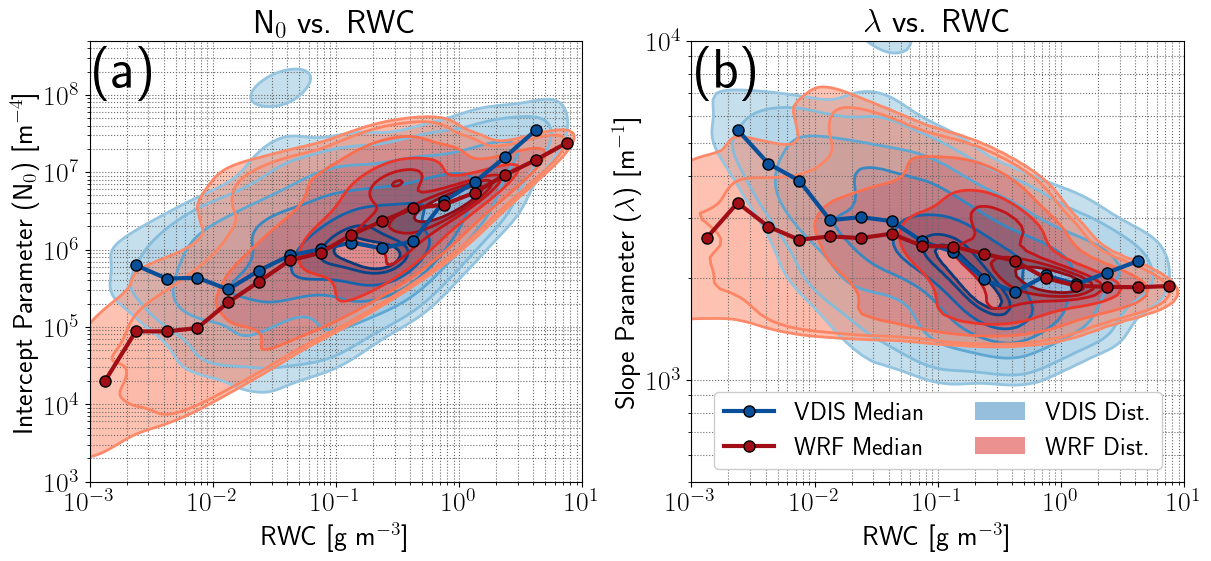

done


In [15]:
# WRF data is already in m^-4 and m^-1.
wrf_rwc = wrf_dict['all_cell_lwc']
wrf_n0 = wrf_dict['all_cell_N0']
wrf_lambda = wrf_dict['all_cell_Lambda']

# VDIS data needs conversion
vdis_rwc = obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['lwc']
vdis_n0_raw = obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['num_concen'] # Units: 1/(m^3 mm)
vdis_lambda_raw = obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['exppsd_slope'] # Units: 1/mm

# Convert VDIS N0 from 1/(m^3 mm) to m^-4
# 1 / (m^3 * mm) * (1000 mm / 1 m) = 1000 / m^4
vdis_n0 = vdis_n0_raw * 1000.0

# Convert VDIS Lambda from 1/mm to m^-1
# 1 / mm * (1000 mm / 1 m) = 1000 / m
vdis_lambda = vdis_lambda_raw * 1000.0

def find_density_levels(density_grid, probability_levels):
    """
    Calculates the density contour levels that enclose given probability masses.

    Args:
        density_grid (np.ndarray): The 2D array of density values from the KDE.
        probability_levels (list or np.ndarray): A list of probabilities
            for which to find the corresponding density level (e.g., [0.50, 0.95]).

    Returns:
        np.ndarray: An array of density values. Plotting contours at these
                    levels will enclose the specified probability mass.
    """
    # Flatten and sort the density grid in descending order
    sorted_densities = np.sort(density_grid.ravel())[::-1]
    
    # Calculate the cumulative sum of densities
    cumulative_mass = np.cumsum(sorted_densities)
    
    # Normalize the cumulative sum to be a CDF (0 to 1)
    total_mass = cumulative_mass[-1]
    if total_mass == 0:
        return np.array([]) # Avoid division by zero for empty grids
    normalized_cdf = cumulative_mass / total_mass
    
    # Find the density levels for each probability
    # np.searchsorted finds the index where the probability level would be inserted
    # to maintain order. We then use this index to find the corresponding density.
    indices = np.searchsorted(normalized_cdf, probability_levels)
    
    # Clip indices to be within the bounds of the sorted_densities array
    indices = np.clip(indices, 0, len(sorted_densities) - 1)
    
    levels = sorted_densities[indices]
    
    # It's better for plotting if levels are sorted ascending
    return np.sort(levels)



def plot_kde_dsd_param(ax, x_data, y_data, x_bins, grid_xlim_log, grid_ylim_log, color, label,
                       probability_levels, min_samples_threshold=10,stat_to_plot='median',):
    """
    Adapted KDE function for DSD parameters N0 or Lambda, where both axes are log.
    """
    # Filter data to be within the grid to avoid KDE artifacts
    valid_mask = (x_data > 10**grid_xlim_log[0]) & (x_data < 10**grid_xlim_log[1]) & \
                 (y_data > 10**grid_ylim_log[0]) & (y_data < 10**grid_ylim_log[1])
    x_data, y_data = x_data[valid_mask], y_data[valid_mask]
    
    if len(x_data) < 2:
        print(f"Skipping KDE for {label}: not enough data points after filtering.")
        return
        
    x_log = np.log10(x_data)
    y_log = np.log10(y_data)
    
    # --- KDE Plotting ---
    xx, yy = np.mgrid[grid_xlim_log[0]:grid_xlim_log[1]:200j, 
                      grid_ylim_log[0]:grid_ylim_log[1]:200j]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    values = np.vstack([x_log, y_log])
    kernel = scipy.stats.gaussian_kde(values)
    f = np.reshape(kernel(positions).T, xx.shape)
    levels = find_density_levels(f, probability_levels)
    
    if len(levels) > 0:
        cmap = plt.get_cmap(color)
        new_cmap = truncate_colormap(cmap, 0.4, 1.0)
        ax.contourf(10**xx, 10**yy, f, cmap=new_cmap, levels=levels, alpha=0.5)
        all_levels = np.append(levels, f.max())
        ax.contour(10**xx, 10**yy, f, cmap=new_cmap, levels=all_levels, linewidths=2.)

    # --- Binned Median Calculation (more robust for skewed DSD params) ---
    #median_y, _, _ = scipy.stats.binned_statistic(x_data, y_data, 'median', bins=x_bins)
    binned_stat, _, _ = scipy.stats.binned_statistic(x_data, y_data, stat_to_plot, bins=x_bins)
    
    # Apply sample count threshold
    counts, _, _ = scipy.stats.binned_statistic(x_data, y_data, 'count', bins=x_bins)
    #median_y[counts < min_samples_threshold] = np.nan
    binned_stat[counts < min_samples_threshold] = np.nan
    # Update the label based on the chosen statistic
    stat_label = 'Median' if stat_to_plot == 'median' else 'Mean'
    x_mid_bins = 10.**(0.5 * (np.log10(x_bins[:-1]) + np.log10(x_bins[1:])))
    #ax.plot(x_mid_bins, median_y, lw=3, marker='o', c=new_cmap(0.8), 
    ax.plot(x_mid_bins, binned_stat, lw=3, marker='o', c=new_cmap(0.8), 
            label=f'{label} {stat_label}', markersize=8, markeredgecolor='k',zorder=10)
            #label=f'{label} Median', markersize=8, markeredgecolor='k',zorder=10)


# --- 3. Setup the Figure ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,5.5), constrained_layout=True)
Fontsize = 20

axlist = [ax1,ax2]
for ax in axlist:
    ax.set_xlabel('RWC [g m$^{-3}$]', fontsize=Fontsize)
    ax.set_xscale('log')
    ax.set_yscale('log')
    ax.tick_params(labelsize=Fontsize)
    ax.grid(which='both', ls='dotted', c='dimgrey')
    ax.set_xlim(1e-3, 1e1)
        
# --- Formatting for N0 plot (ax1) ---
ax1.set_ylabel('Intercept Parameter (N$_0$) [m$^{-4}$]', fontsize=Fontsize)
ax1.set_ylim(1e4, 1e9)

# --- Formatting for Lambda plot (ax2) ---
ax2.set_ylabel('Slope Parameter ($\lambda$) [m$^{-1}$]', fontsize=Fontsize)
ax2.set_ylim(1e2, 2e4)


# --- 4. Define Grid, Bins, and Plotting Parameters ---
prob_levels = [0.05, 0.1, 0.25, 0.50, 0.75, 0.90, 0.95]
lwc_bins = 10.**np.arange(-3, 1.25, 0.25)
MIN_SAMPLES = 5

# Define generous grid limits for KDE calculation (in log10 space)
GRID_RWC_LOG = (np.log10(1e-4), np.log10(5e1))
GRID_N0_LOG = (np.log10(1e3), np.log10(1e10))
GRID_LAMBDA_LOG = (np.log10(1e1), np.log10(5e4))

# --- 5. Plot the Data ---

stat='median'
#stat='mean'

# Plot N0 vs RWC on ax1
plot_kde_dsd_param(ax1, vdis_rwc, vdis_n0, lwc_bins, GRID_RWC_LOG, GRID_N0_LOG, 'Blues', 'VDIS', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)
plot_kde_dsd_param(ax1, wrf_rwc, wrf_n0, lwc_bins, GRID_RWC_LOG, GRID_N0_LOG, 'Reds', 'WRF', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)
ax1.set_title(r'N$_0$ vs. RWC', fontsize=Fontsize*1.2)

# Plot Lambda vs RWC on ax2
plot_kde_dsd_param(ax2, vdis_rwc, vdis_lambda, lwc_bins, GRID_RWC_LOG, GRID_LAMBDA_LOG, 'Blues', 'VDIS', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)
plot_kde_dsd_param(ax2, wrf_rwc, wrf_lambda, lwc_bins, GRID_RWC_LOG, GRID_LAMBDA_LOG, 'Reds', 'WRF', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)
ax2.set_title(r'$\lambda$ vs. RWC', fontsize=Fontsize*1.2)


# --- 6. Create a Unified Legend ---
handles, labels = [], []
for ax in [ax1, ax2]:
    h, l = ax.get_legend_handles_labels()
    for i, label in enumerate(l):
        if label not in labels:
            labels.append(label)
            handles.append(h[i])

# Get the base colormaps
cmap_vdis = plt.get_cmap('Blues')
cmap_wrf = plt.get_cmap('Reds')

# Create the truncated colormaps, exactly as done in the plotting function
new_cmap_vdis = truncate_colormap(cmap_vdis, 0.4, 1.0)
new_cmap_wrf = truncate_colormap(cmap_wrf, 0.4, 1.0)


handles_ax2, labels_ax2 = ax2.get_legend_handles_labels()
patches_ax2 = [
    Patch(facecolor=new_cmap_vdis(0.5), label=r'VDIS Dist.', alpha=0.5),
    Patch(facecolor=new_cmap_wrf(0.5), label=r'WRF Dist.', alpha=0.5),
]
handles_ax2.extend(patches_ax2)
ax2.legend(handles=handles_ax2 + patches_ax2, 
           labels=labels_ax2 + ['VDIS Dist.', 'WRF Dist.'], 
           loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=2, 
           fontsize=Fontsize*0.9, framealpha=1)


labs = ['(a)','(b)']
for i,ax in enumerate(axlist):
    ax.text(0.01,0.99,labs[i],transform=ax.transAxes,ha='left',va='top',fontsize=Fontsize*2.)

ax1.set_ylim(1.e3,5.e8)
ax2.set_ylim(5.e2,1.e4)

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
outfile = save_path+f'fig_vdis_wrf_rwc_N0_lambda_{stat}.png'
#plt.savefig(outfile,dpi=300)
plt.show()
plt.close()
print('done')

# Grab DSD parameters and raw DSDs from dictionaries
## Construct parameterized DSDs from gamma and exponential parameters

In [16]:
import scipy.special
from scipy.special import gamma as gamma_function

In [17]:
obs_dict_3km['vdis_dict']['vdis_matched_expand_dict'].keys()

dict_keys(['time', 'reflectivity_factor_cband20c', 'lwc', 'bringi_conv_stra_flag', 'mass_weighted_mean_diameter', 'gammapsd_slope', 'num_concen', 'norm_num_concen', 'gammapsd_shape', 'med_diameter', 'total_droplet_concentration', 'exppsd_slope', 'rain_rate'])

In [18]:
# Make arbitrary diameter grid to construct parametric DSDs
diam = np.arange(0,9.01,0.01) # mm


#===============================
# VDIS
#===============================
vdis_gammadsd_shape = obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['gammapsd_shape'].copy() # - 1D (number_of_samples)
vdis_gammadsd_slope = obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['gammapsd_slope'].copy() # 1/mm - 1D (number_of_samples)
vdis_gammadsd_norm_num_concen = obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['norm_num_concen'].copy() 
vdis_expdsd_slope = obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['exppsd_slope'].copy() # 1/mm - 1D (number_of_samples)
vdis_expdsd_intercept = obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['num_concen'].copy() 
vdis_num_density = obs_dict_3km['vdis_dict']['vdis0_matched_expand_dict']['num_density'].copy() # 1/(m^3 mm) - 2D (number_of_samples x number_of_bins)
vdis_drop_diameter = obs_dict_3km['vdis_dict']['vdis0_matched_expand_dict']['drop_diameter'].copy() # mm  - 1D (number_of_bins)
vdis_lwc = obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['lwc'].copy() # g/m^3 - 1D (number_of_samples)
vdis_num_drops = obs_dict_3km['vdis_dict']['vdis0_matched_expand_dict']['num_drops'].copy() # number of drops per bin
vdis_dbz = obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['reflectivity_factor_cband20c'].copy()
num_vdis_samps = len(vdis_lwc)
print('# of VDIS samples prior to filtering:',num_vdis_samps)

tot_drops_per_bin = np.sum(vdis_num_drops,axis=0)
num_drop_thresh = 10.
dumid = np.where(tot_drops_per_bin < num_drop_thresh)
print(f'# of VDIS bins w/ less than {num_drop_thresh} drops:',np.size(dumid))
if np.size(dumid) > 0.:
    dumid = dumid[0]
    vdis_num_density[:,dumid] = 0.0
    
# integrate number density
vdis_int_num_density = scipy.integrate.trapezoid(vdis_num_density,vdis_drop_diameter)

zero_id = np.where(vdis_int_num_density == 0.)
if np.size(zero_id) > 0.:
    nonzero_id = np.where(vdis_int_num_density > 0.)[0]
    vdis_int_num_density = vdis_int_num_density[nonzero_id]
    vdis_num_drops = vdis_num_drops[nonzero_id]
    vdis_lwc = vdis_lwc[nonzero_id]
    vdis_num_density = vdis_num_density[nonzero_id,:]
    vdis_expdsd_intercept = vdis_expdsd_intercept[nonzero_id]
    vdis_expdsd_slope = vdis_expdsd_slope[nonzero_id]
    vdis_gammadsd_norm_num_concen = vdis_gammadsd_norm_num_concen[nonzero_id]
    vdis_gammadsd_slope = vdis_gammadsd_slope[nonzero_id]
    vdis_gammadsd_shape = vdis_gammadsd_shape[nonzero_id]
    vdis_dbz = vdis_dbz[nonzero_id]


num_vdis_samps = len(vdis_lwc)
print('# of VDIS samples after filtering:',num_vdis_samps)


# Construct Exponential DSD
vdis_exp_dsd = np.zeros((num_vdis_samps,len(diam)))
for ii in range(num_vdis_samps):
    vdis_exp_dsd[ii,:] = vdis_expdsd_intercept[ii]*np.exp(-vdis_expdsd_slope[ii]*diam)

# Construct Gamma DSD
vdis_gammadsd_mu = vdis_gammadsd_shape[:,np.newaxis]
vdis_gammadsd_lambda = vdis_gammadsd_slope[:,np.newaxis]
vdis_gammadsd_Nw = vdis_gammadsd_norm_num_concen[:,np.newaxis]

four_plus_mu = 4 + vdis_gammadsd_mu
with np.errstate(invalid='ignore'):
    f_mu = (6 / 256) * (four_plus_mu**four_plus_mu) / gamma_function(four_plus_mu)
    term2 = (diam * vdis_gammadsd_lambda / four_plus_mu)**vdis_gammadsd_mu
vdis_gamma_dsd = (vdis_gammadsd_Nw * f_mu) * term2 * np.exp(-vdis_gammadsd_lambda * diam)
vdis_gamma_dsd[:,0] = 0.0 # Needed because sometimes th4e first value is computed as infinity

# Compute mean and standard deviation of DSDs
# Gamma
vdis_gamma_dsd_mean = np.mean(vdis_gamma_dsd,axis=0)
vdis_gamma_dsd_std = np.std(vdis_gamma_dsd,axis=0)
# Exponential
vdis_exp_dsd_mean = np.mean(vdis_exp_dsd,axis=0)
vdis_exp_dsd_std = np.std(vdis_exp_dsd,axis=0)
# Raw, native-grid DSDs (not parametric ones)
dum = vdis_num_density.copy()
vdis_dsd_mean = np.mean(dum,axis=0)
vdis_dsd_std = np.std(dum,axis=0)
vdis_dsd_mean[vdis_dsd_mean == 0.] = np.nan
vdis_dsd_std[vdis_dsd_mean == 0.] = np.nan

# Compute integrated reflectivity & ZSDs
raw_zsd = dum * (vdis_drop_diameter**6.)
exp_zsd = vdis_exp_dsd * (diam**6.)
gamma_zsd = vdis_gamma_dsd * (diam**6.)
raw_ze = scipy.integrate.trapezoid(raw_zsd,vdis_drop_diameter,axis=1)
exp_ze = scipy.integrate.trapezoid(exp_zsd,diam,axis=1)
gamma_ze = scipy.integrate.trapezoid(gamma_zsd,diam,axis=1)
vdis_raw_dbz = 10.*np.log10(raw_ze)
vdis_exp_dbz = 10.*np.log10(exp_ze)
vdis_gamma_dbz = 10.*np.log10(gamma_ze)


vdis_data = {
    'raw_dsd': vdis_num_density,
    'raw_diam': vdis_drop_diameter,
    'lwc': vdis_lwc,
    'exp_slope': vdis_expdsd_slope,
    'exp_intercept': vdis_expdsd_intercept,
    'gamma_slope': vdis_gammadsd_slope,
    'gamma_shape': vdis_gammadsd_shape,
    'norm_intercept': vdis_gammadsd_norm_num_concen,
    'dbz': vdis_dbz,
    'dsd_exp':vdis_exp_dsd,
    'dsd_gamma':vdis_gamma_dsd,
    'func_diam':diam,
    'dbz_int':vdis_raw_dbz,
    'exp_dbz_int':vdis_exp_dbz,
    'gamma_dbz_int':vdis_gamma_dbz,
    'num_drops':vdis_num_drops,
}


#===============================
# LD
#===============================
ld_gammadsd_slope = obs_dict_3km['ld_dict']['ld_matched_expand_dict']['gammapsd_slope'].copy() # 1/mm - 1D (number_of_samples)
ld_gammadsd_norm_num_concen = obs_dict_3km['ld_dict']['ld_matched_expand_dict']['norm_num_concen'].copy() 
ld_expdsd_intercept = obs_dict_3km['ld_dict']['ld_matched_expand_dict']['num_concen'].copy() 
ld_gammadsd_shape = obs_dict_3km['ld_dict']['ld_matched_expand_dict']['gammapsd_shape'].copy() # - 1D (number_of_samples)
ld_expdsd_slope = obs_dict_3km['ld_dict']['ld_matched_expand_dict']['exppsd_slope'].copy() # 1/mm - 1D (number_of_samples)
ld_num_density = obs_dict_3km['ld_dict']['ld0_matched_expand_dict']['number_density_drops'].copy() # 1/(m^3 mm) - 2D (number_of_samples x number_of_bins)
ld_drop_diameter = obs_dict_3km['ld_dict']['ld0_matched_expand_dict']['particle_size'].copy() # mm    - 1D (number_of_bins)
ld_lwc = obs_dict_3km['ld_dict']['ld_matched_expand_dict']['lwc'].copy() # g/m^3 - 1D (number_of_samples)
#ld_num_drops = obs_dict_3km['ld_dict']['ld0_matched_expand_dict']['num_drops'].copy()
ld_dbz = obs_dict_3km['ld_dict']['ld_matched_expand_dict']['reflectivity_factor_cband20c'].copy()
# For whatever reason, the Laser Disdrometer gives a bin width
ld_drop_diameter_dD = obs_dict_3km['ld_dict']['ld0_matched_expand_dict']['class_size_width'].copy() # mm - 1D (number_of_bins - 1)

num_ld_samps = len(ld_lwc)
print('# of LD samples before filtering:',num_ld_samps)

#tot_drops_per_bin = np.sum(ld_num_drops,axis=0)
tot_num_density = np.sum(ld_num_density,axis=0)
num_density_thresh = 1.
#dumid = np.where(tot_drops_per_bin < num_drop_thresh)
dumid = np.where(tot_num_density < num_density_thresh)
print(f'# of LD bins w/ less total number density less than {num_density_thresh} m^-3 mm^-1:',np.size(dumid))
if np.size(dumid) > 0.:
    dumid = dumid[0]
    ld_num_density[:,dumid] = 0.0

# integrate number density
ld_int_num_density = scipy.integrate.trapezoid(ld_num_density,ld_drop_diameter)

zero_id = np.where(ld_int_num_density == 0.)
if np.size(zero_id) > 0.:
    nonzero_id = np.where(ld_int_num_density > 0.)[0]
    ld_int_num_density = ld_int_num_density[nonzero_id]
    #ld_num_drops = ld_num_drops[nonzero_id]
    ld_lwc = ld_lwc[nonzero_id]
    ld_num_density = ld_num_density[nonzero_id,:]
    ld_expdsd_intercept = ld_expdsd_intercept[nonzero_id]
    ld_expdsd_slope = ld_expdsd_slope[nonzero_id]
    ld_gammadsd_norm_num_concen = ld_gammadsd_norm_num_concen[nonzero_id]
    ld_gammadsd_slope = ld_gammadsd_slope[nonzero_id]
    ld_gammadsd_shape = ld_gammadsd_shape[nonzero_id]
    ld_dbz = ld_dbz[nonzero_id]

num_ld_samps = len(ld_lwc)
print('# of LD samples after filtering:',num_ld_samps)


# Construct Exponential DSD
ld_exp_dsd = np.zeros((num_ld_samps,len(diam)))
for ii in range(num_ld_samps):
    ld_exp_dsd[ii,:] = ld_expdsd_intercept[ii]*np.exp(-ld_expdsd_slope[ii]*diam)


# Construct Gamma DSD
ld_gammadsd_mu = ld_gammadsd_shape[:,np.newaxis]
ld_gammadsd_lambda = ld_gammadsd_slope[:,np.newaxis]
ld_gammadsd_Nw = ld_gammadsd_norm_num_concen[:,np.newaxis]

four_plus_mu = 4 + ld_gammadsd_mu
with np.errstate(invalid='ignore'):
    f_mu = (6 / 256) * (four_plus_mu**four_plus_mu) / gamma_function(four_plus_mu)
    term2 = (diam * ld_gammadsd_lambda / four_plus_mu)**ld_gammadsd_mu
ld_gamma_dsd = (ld_gammadsd_Nw * f_mu) * term2 * np.exp(-ld_gammadsd_lambda * diam)
ld_gamma_dsd[:,0] = 0.0 # Needed because sometimes th4e first value is computed as infinity
    
# Compute mean and standard deviation of DSDs
# Gamma
ld_gamma_dsd_mean = np.mean(ld_gamma_dsd,axis=0)
ld_gamma_dsd_std = np.std(ld_gamma_dsd,axis=0)
# Exponential
ld_exp_dsd_mean = np.mean(ld_exp_dsd,axis=0)
ld_exp_dsd_std = np.std(ld_exp_dsd,axis=0)
# Raw, native-grid DSDs (not parametric ones)
dum = ld_num_density.copy()
ld_dsd_mean = np.mean(dum,axis=0)
ld_dsd_std = np.std(dum,axis=0)
ld_dsd_mean[ld_dsd_mean == 0.] = np.nan
ld_dsd_std[ld_dsd_mean == 0.] = np.nan

# Compute integrated reflectivity & ZSDs
raw_zsd = dum * (ld_drop_diameter**6.)
exp_zsd = ld_exp_dsd * (diam**6.)
gamma_zsd = ld_gamma_dsd * (diam**6.)
raw_ze = scipy.integrate.trapezoid(raw_zsd,ld_drop_diameter,axis=1)
exp_ze = scipy.integrate.trapezoid(exp_zsd,diam,axis=1)
gamma_ze = scipy.integrate.trapezoid(gamma_zsd,diam,axis=1)
ld_raw_dbz = 10.*np.log10(raw_ze)
ld_exp_dbz = 10.*np.log10(exp_ze)
ld_gamma_dbz = 10.*np.log10(gamma_ze)




ld_data = {
    'raw_dsd': ld_num_density,
    'raw_diam': ld_drop_diameter,
    'lwc': ld_lwc,
    'exp_slope': ld_expdsd_slope,
    'exp_intercept': ld_expdsd_intercept,
    'gamma_slope': ld_gammadsd_slope,
    'gamma_shape': ld_gammadsd_shape,
    'norm_intercept': ld_gammadsd_norm_num_concen,
    'dbz': ld_dbz,
    'dsd_exp':ld_exp_dsd,
    'dsd_gamma':ld_gamma_dsd,
    'func_diam':diam,
    'dbz_int':ld_raw_dbz,
    'exp_dbz_int':ld_exp_dbz,
    'gamma_dbz_int':ld_gamma_dbz,
    
}

# of VDIS samples prior to filtering: 1365
# of VDIS bins w/ less than 10.0 drops: 14
# of VDIS samples after filtering: 1361
# of LD samples before filtering: 1534
# of LD bins w/ less total number density less than 1.0 m^-3 mm^-1: 7
# of LD samples after filtering: 1534


# WRF DSDs

In [25]:
qr = wrf_dict['all_cell_qr'].copy()  # kg/kg
nr = wrf_dict['all_cell_nr'].copy()  # /kg
rho_air = wrf_dict['all_cell_rho_air'].copy()  # kg/m^3
mu_r = 0.  # shape parameter

rho_w = 1000.0  # kg/m^3
bm_r = 3.
am_r = np.pi * rho_w / 6.0  # kg/m^3
D# = np.arange(0, 9.01, 0.01)*1.e-3  # m
D = np.arange(0.01, 9.01, 0.01)*1.e-3
dD = np.diff(D)[0]

Nt = nr * rho_air  # #/m^3
RWC = qr * rho_air  # kg/m^3

Lambda = (am_r * (Nt / RWC) * scipy.special.gamma(mu_r + bm_r + 1.) / scipy.special.gamma(mu_r + 1.) ) ** (1.0 / bm_r)  # 1/m
N0 = Nt * (Lambda ** (mu_r + 1.)) / scipy.special.gamma(mu_r + 1.)  # 1/m^4

# Construct dsds: units #/m^4
num_wrf_samps = len(N0)
wrf_dsds = np.zeros((num_wrf_samps, len(D)))
for ii in range(num_wrf_samps):
    wrf_dsds[ii, :] = N0[ii] * (D ** mu_r) * np.exp(-Lambda[ii] * (D) )  # #/m^4
wrf_dsds = wrf_dsds*1.e-3 # /m^3 /mm
wrf_mean_dsd = np.mean(wrf_dsds, axis=0)
wrf_std_dsd = np.std(wrf_dsds, axis=0)

# Mass-weighted mean diameter (mm)
M4 = N0 * scipy.special.gamma(mu_r + 4. + 1.) / Lambda ** (mu_r + 4. + 1.) # m^-3
M3 = N0 * scipy.special.gamma(mu_r + 3. + 1.) / Lambda  ** (mu_r + 3. + 1.) # m^-2
wrf_Dm = M4/M3 # m 
wrf_Dm = wrf_Dm*1.e3 # mm

wrf_dict['wrf_dsds'] = wrf_dsds
wrf_dict['wrf_mean_dsd'] = wrf_mean_dsd
wrf_dict['wrf_std_dsd'] = wrf_std_dsd
wrf_dict['all_cell_Dm'] = wrf_Dm
wrf_dict['all_cell_N0'] = N0
wrf_dict['all_cell_Lambda'] = Lambda

In [26]:
if False:
    # Make arbitrary diameter grid to construct parametric DSDs
    diam = np.arange(0,9.01,0.01) # mm
    
    vdis_gammadsd_shape = obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['gammapsd_shape'].copy() # - 1D (number_of_samples)
    vdis_gammadsd_slope = obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['gammapsd_slope'].copy() # 1/mm - 1D (number_of_samples)
    vdis_gammadsd_norm_num_concen = obs_dict_3km['vdis_dict']['vdis_matched_expand_dict']['norm_num_concen'].copy() 
    vdis_gammadsd_shape = vdis_gammadsd_shape[:,np.newaxis]
    vdis_gammadsd_slope = vdis_gammadsd_slope[:,np.newaxis]
    vdis_gammadsd_norm_num_concen = vdis_gammadsd_norm_num_concen[:,np.newaxis]
    
    four_plus_mu = 4 + vdis_gammadsd_shape
    with np.errstate(invalid='ignore'):
        f_mu = (6 / 256) * (four_plus_mu**four_plus_mu) / gamma_function(four_plus_mu)
        term2 = (diam * vdis_gammadsd_slope / four_plus_mu)**vdis_gammadsd_shape
    vdis_gamma_dsd = (vdis_gammadsd_norm_num_concen * f_mu) * term2 * np.exp(-vdis_gammadsd_slope * diam)
    vdis_gamma_dsd[:,0] = 0.0 # Needed because sometimes th4e first value is computed as infinity
    
    gamma_zsd = vdis_gamma_dsd * (diam**6.)
    gamma_ze = scipy.integrate.trapezoid(gamma_zsd,x=diam,axis=1)
    gamma_dbz = 10.*np.log10(gamma_ze)
    print(np.min(gamma_dbz),np.max(gamma_dbz))

In [27]:
def find_density_levels(density_grid, probability_levels):
    """
    Calculates the density contour levels that enclose given probability masses.

    Args:
        density_grid (np.ndarray): The 2D array of density values from the KDE.
        probability_levels (list or np.ndarray): A list of probabilities
            for which to find the corresponding density level (e.g., [0.50, 0.95]).

    Returns:
        np.ndarray: An array of density values. Plotting contours at these
                    levels will enclose the specified probability mass.
    """
    # Flatten and sort the density grid in descending order
    sorted_densities = np.sort(density_grid.ravel())[::-1]
    
    # Calculate the cumulative sum of densities
    cumulative_mass = np.cumsum(sorted_densities)
    
    # Normalize the cumulative sum to be a CDF (0 to 1)
    total_mass = cumulative_mass[-1]
    if total_mass == 0:
        return np.array([]) # Avoid division by zero for empty grids
    normalized_cdf = cumulative_mass / total_mass
    
    # Find the density levels for each probability
    # np.searchsorted finds the index where the probability level would be inserted
    # to maintain order. We then use this index to find the corresponding density.
    indices = np.searchsorted(normalized_cdf, probability_levels)
    
    # Clip indices to be within the bounds of the sorted_densities array
    indices = np.clip(indices, 0, len(sorted_densities) - 1)
    
    levels = sorted_densities[indices]
    
    # It's better for plotting if levels are sorted ascending
    return np.sort(levels)

def plot_kde_and_mean_probability(ax, x_data, y_data, x_bins, 
                                  # NEW: Pass in the grid limits
                                  grid_xlim_log, grid_ylim, color, label, 
                                  probability_levels=[0.50, 0.90, 0.99], 
                                  min_samples_threshold=10,
                                  stat_to_plot='mean'):
    """
    Calculates and plots a joint KDE and a binned mean line, ensuring the mean
    is only calculated for bins with a minimum number of samples.
    
    Args:
        min_samples_threshold (int): The minimum number of data points required in
            a bin to calculate and plot the mean for that bin.
    """
    # --- KDE Plotting (no changes here) ---
    x_log = np.log10(x_data)
    y_data_clean = y_data.copy()

    xmin, xmax = np.min(x_log), np.max(x_log)
    ymin, ymax = np.min(y_data_clean), np.max(y_data_clean)
    
    #xx, yy = np.mgrid[xmin:xmax:150j, ymin:ymax:150j] 
    xx, yy = np.mgrid[grid_xlim_log[0]:grid_xlim_log[1]:200j, 
                      grid_ylim[0]:grid_ylim[1]:200j]
    
    positions = np.vstack([xx.ravel(), yy.ravel()])
    values = np.vstack([x_log, y_data_clean])
    
    if values.shape[1] < 2:
        print(f"Skipping KDE for {label}: not enough data points.")
        return

    kernel = scipy.stats.gaussian_kde(values)
    f = np.reshape(kernel(positions).T, xx.shape)
    
    levels = find_density_levels(f, probability_levels)
    if len(levels) == 0:
        print(f"Skipping contour plot for {label}: could not determine levels.")
    else:
        cmap = plt.get_cmap(color)
        new_cmap = truncate_colormap(cmap, 0.4, 1.0)
        ax.contourf(10**xx, yy, f, cmap=new_cmap, levels=levels, alpha=0.5)
        all_levels = np.append(levels, f.max())
        #ax.contour(10**xx, yy, f, cmap=new_cmap, levels=all_levels, linewidths=0.8)
        ax.contour(10**xx, yy, f, cmap=new_cmap, levels=all_levels, linewidths=2)

    # --- Binned Mean Calculation with Thresholding ---
    x_mid_bins = 10.**(0.5 * (np.log10(x_bins[:-1]) + np.log10(x_bins[1:])))
    mean_y = []
    median_y = []
    
    for i in range(len(x_bins) - 1):
        mask = (x_data >= x_bins[i]) & (x_data < x_bins[i+1])
        num_samples_in_bin = np.sum(mask)

        # Check if the bin meets the minimum sample count threshold
        if num_samples_in_bin < min_samples_threshold:
            mean_y.append(np.nan)
            median_y.append(np.nan)
            continue
        
        # This calculation only proceeds for valid bins
        y_linear = 10**(y_data_clean[mask] / 10.)
        mean_y_linear = np.mean(y_linear)
        mean_y.append(10. * np.log10(mean_y_linear))
        median_y.append(np.median(y_data_clean[mask]))

    if stat_to_plot == 'mean':
        ax.plot(x_mid_bins, mean_y, lw=3, marker='o', c=new_cmap(0.8), label=f'{label} Mean $Z_e$', markersize=8, markeredgecolor='k',zorder=10)
    elif stat_to_plot == 'median':
        ax.plot(x_mid_bins, median_y, lw=3, marker='o', c=new_cmap(0.8), label=f'{label} Med. $Z_e$', markersize=8, markeredgecolor='k',zorder=10)


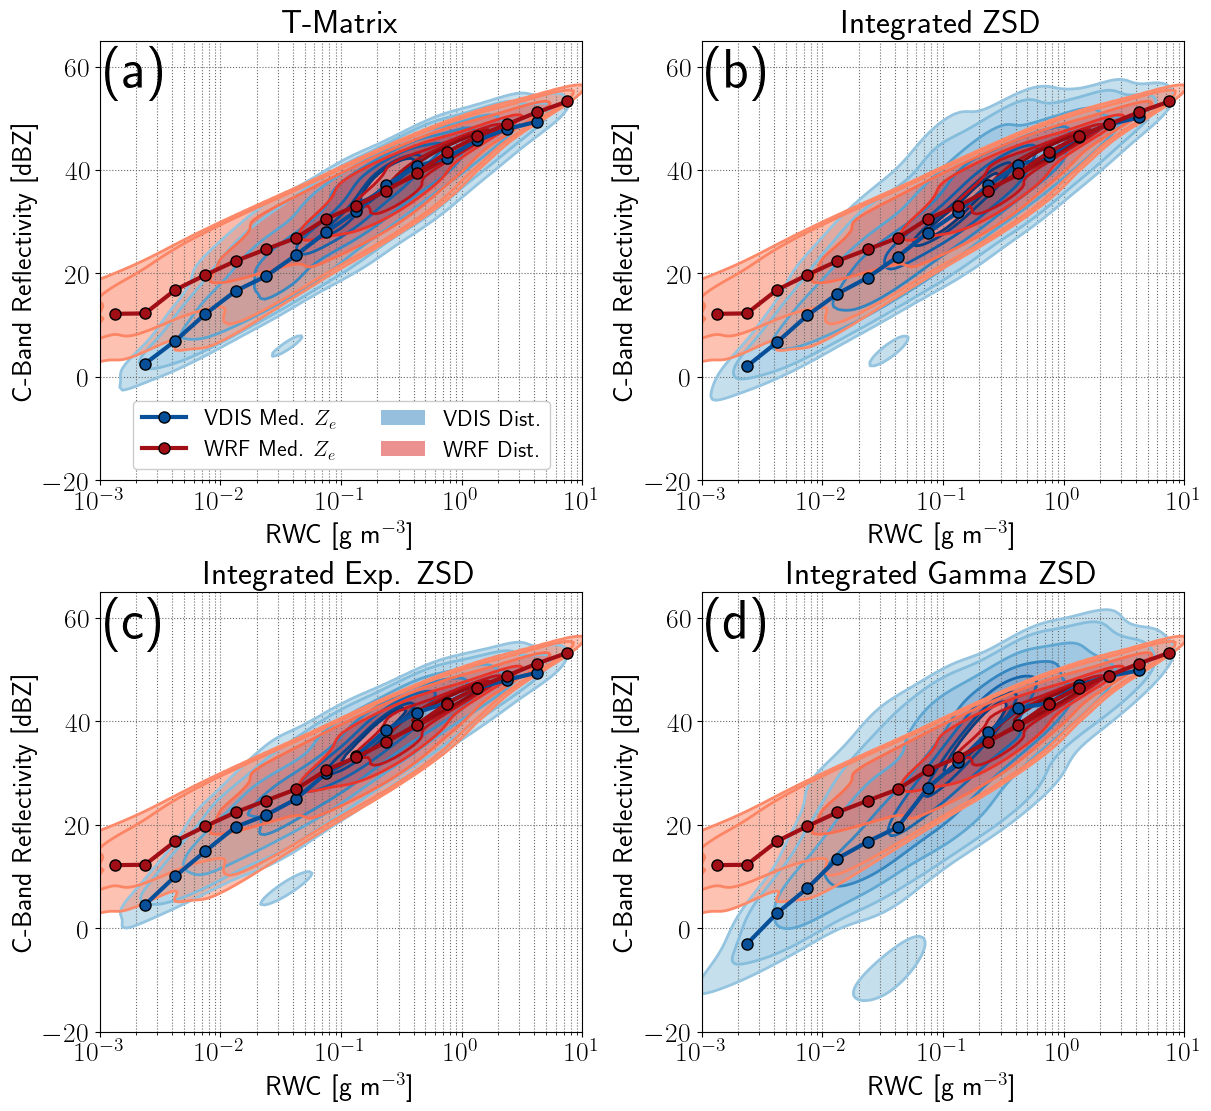

done


In [55]:
# --- Setup Figure ---
fig, axs = plt.subplots(2, 2, figsize=(12,11), constrained_layout=True)
Fontsize = 20
axlist = np.ndarray.flatten(axs)
RWC_LIMS = [1e-3, 1e1]
DBZ_LIMS = [-20, 65]
for ax in axlist:
    ax.grid(which='both', ls='dotted', c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_xlabel(r'RWC [g m$^{-3}$]', fontsize=Fontsize)
    ax.set_ylabel(r'C-Band Reflectivity [dBZ]', fontsize=Fontsize)
    ax.set_xscale('log')
    #ax.set_xlim(1e-4, 1e1)
    ax.set_ylim(-40, 65)
    # Set the final view limits for each axis
    ax.set_xlim(RWC_LIMS)
    ax.set_ylim(DBZ_LIMS)
# --- Define Bins ---
exp = np.arange(-3, 1.25, 0.25)
lwc_bins = 10.**exp
ax1 = axlist[0]
ax2 = axlist[1]
ax3 = axlist[2]
ax4 = axlist[3]

# === DEFINE THE SINGLE, WIDE GRID & PLOT LIMITS ===
# The GRID must be wide enough for the widest contour.
# The PLOT limits can be the same or slightly tighter.
# NOTE: The X-limits for the grid must be in log10 space!
GRID_XLIM_LOG = (np.log10(1e-5), np.log10(5e1)) # Generously wide in log space
GRID_YLIM = (-40, 80)                         # Generously wide

# Define the probability levels you want to visualize
# This will draw contours enclosing 50%, 90%, and 99% of the data.
prob_levels = [0.05, 0.1, 0.25, 0.50, 0.75, 0.90, 0.95]

# --- Plot Data ---
MIN_SAMPLES=5

#stat = 'mean'
stat = 'median'

# Plot VDIS
plot_kde_and_mean_probability(ax1, vdis_data['lwc'], vdis_data['dbz'], lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Blues', 'VDIS', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)
plot_kde_and_mean_probability(ax2, vdis_data['lwc'], vdis_data['dbz_int'], lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Blues', 'VDIS', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)
plot_kde_and_mean_probability(ax3, vdis_data['lwc'], vdis_data['exp_dbz_int'], lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Blues', 'VDIS', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)
plot_kde_and_mean_probability(ax4, vdis_data['lwc'], vdis_data['gamma_dbz_int'], lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Blues', 'VDIS', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)

# Plot WRF
plot_kde_and_mean_probability(ax1, wrf_dict['all_cell_lwc'], wrf_dict['all_cell_dbz'], lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Reds', 'WRF', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)
plot_kde_and_mean_probability(ax2, wrf_dict['all_cell_lwc'], wrf_dict['all_cell_dbz'], lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Reds', 'WRF', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)
plot_kde_and_mean_probability(ax3, wrf_dict['all_cell_lwc'], wrf_dict['all_cell_dbz'], lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Reds', 'WRF', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)
plot_kde_and_mean_probability(ax4, wrf_dict['all_cell_lwc'], wrf_dict['all_cell_dbz'], lwc_bins, GRID_XLIM_LOG, GRID_YLIM,'Reds', 'WRF', prob_levels, min_samples_threshold=MIN_SAMPLES,stat_to_plot=stat)


# --- Titles and Legends ---
ax1.set_title(r'T-Matrix', fontsize=Fontsize*1.2)
ax2.set_title(r'Integrated ZSD', fontsize=Fontsize*1.2)
ax3.set_title(r'Integrated Exp. ZSD', fontsize=Fontsize*1.2)
ax4.set_title(r'Integrated Gamma ZSD', fontsize=Fontsize*1.2)

# Create a single, clear legend
handles, labels = [], []
#for ax in [ax1, ax2, ax3]:
for ax in [ax1,ax2]:
    h, l = ax.get_legend_handles_labels()
    for i, label in enumerate(l):
        if label not in labels:
            labels.append(label)
            handles.append(h[i])

# Add patches for the KDE areas

# Get the base colormaps
cmap_vdis = plt.get_cmap('Blues')
cmap_wrf = plt.get_cmap('Reds')

# Create the truncated colormaps, exactly as done in the plotting function
new_cmap_vdis = truncate_colormap(cmap_vdis, 0.4, 1.0)
new_cmap_wrf = truncate_colormap(cmap_wrf, 0.4, 1.0)

if True:
    # Plot (a)
    handles_ax1, labels_ax1 = ax1.get_legend_handles_labels()
    patches_ax1 = [
        Patch(facecolor=new_cmap_vdis(0.5), label=r'VDIS Dist.', alpha=0.5),
        Patch(facecolor=new_cmap_wrf(0.5), label=r'WRF Dist.', alpha=0.5),
    ]
    handles_ax1.extend(patches_ax1)
    ax1.legend(handles=handles_ax1 + patches_ax1, 
               labels=labels_ax1 + ['VDIS Dist.', 'WRF Dist.'], 
               loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=2, 
               fontsize=Fontsize*0.8, framealpha=1)
   # Plot (b)
    handles_ax2, labels_ax2 = ax2.get_legend_handles_labels()
    patches_ax2 = [
        Patch(facecolor=new_cmap_vdis(0.5), label=r'VDIS Dist.', alpha=0.5),
        Patch(facecolor=new_cmap_wrf(0.5), label=r'WRF Dist.', alpha=0.5),
    ]
    handles_ax2.extend(patches_ax2)
    #ax2.legend(handles=handles_ax2 + patches_ax2, 
    #           labels=labels_ax2 + ['VDIS Dist.', 'WRF Dist.'], 
    #           loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=2, 
    #           fontsize=Fontsize*0.8, framealpha=1)
   # Plot (c)
    handles_ax3, labels_ax3 = ax3.get_legend_handles_labels()
    patches_ax3 = [
        Patch(facecolor=new_cmap_vdis(0.5), label=r'VDIS Dist.', alpha=0.5),
        Patch(facecolor=new_cmap_wrf(0.5), label=r'WRF Dist.', alpha=0.5),
    ]
    handles_ax3.extend(patches_ax3)
    #ax3.legend(handles=handles_ax3 + patches_ax3, 
    #           labels=labels_ax3 + ['VDIS Dist.', 'WRF Dist.'], 
    #           loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=2, 
    #           fontsize=Fontsize*0.8, framealpha=1)
   # Plot (d)
    handles_ax4, labels_ax4 = ax4.get_legend_handles_labels()
    patches_ax4 = [
        Patch(facecolor=new_cmap_vdis(0.5), label=r'VDIS Dist.', alpha=0.5),
        Patch(facecolor=new_cmap_wrf(0.5), label=r'WRF Dist.', alpha=0.5),
    ]
    handles_ax4.extend(patches_ax4)
    #ax4.legend(handles=handles_ax4 + patches_ax4, 
    #           labels=labels_ax4 + ['VDIS Dist.', 'WRF Dist.'], 
    #           loc='lower center', bbox_to_anchor=(0.5, 0.0), ncol=2, 
    #           fontsize=Fontsize*0.8, framealpha=1)

    

#labs = ['(a)','(b)','(c)']
labs = ['(a)','(b)','(c)','(d)']
for i,ax in enumerate(axlist):
    ax.text(0.01,0.99,labs[i],transform=ax.transAxes,ha='left',va='top',fontsize=Fontsize*2.)
    ax.set_ylim(-20,65)

save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
outfile = save_path+f'fig_vdis_wrf_dbz_rwc_TMat_ZSD_Exp_Gamma_{stat}.png'
#plt.savefig(outfile,dpi=300)
plt.show()
plt.close()
print('done')

In [52]:
# Define RWC bins and labels
rwc_bins = [1e-3, 1e-2, 1e-1, 1e0, np.inf]
rwc_labels = [r"10$^{-3}$ to 10$^{-2}$", r"10$^{-2}$ to 10$^{-1}$", r"10$^{-1}$ to 1.0", r"$>$ 1.0"]
diam_plot = np.arange(0.01, 9.01, 0.01)

dis_color='black'
exp_color='teal'
gam_color='darkgoldenrod'
wrf_color='tomato'

# --- 2. Helper Functions ---
def get_binned_indices(lwc_array, rwc_bins):
    """Finds the indices of samples that fall into each RWC bin."""
    indices_by_bin = []
    for i in range(len(rwc_bins) - 1):
        mask = (lwc_array >= rwc_bins[i]) & (lwc_array < rwc_bins[i+1])
        indices_by_bin.append(np.where(mask)[0])
    return indices_by_bin


def calculate_plot_data(ax_row, disdro_data, wrf_data, disdro_indices, wrf_indices, diam_plot, column_index, Fontsize):
    """
    Calculates and plots DSD/MSD/ZSD moments for disdrometer and WRF,
    preserving the original complex text layout.
    """
    # Constants
    am_r = np.pi * 1000.0 / 6.0
    bm_r = 3.0
    small_positive_number = 1.e-20

    # --- Disdrometer DSD Calculations ---
    raw_dsd_subset = disdro_data['raw_dsd'][disdro_indices]

    # Old Logic that used the total number of drops across all DSDs in a bin
    #num_drops = np.sum(disdro_data['num_drops'][disdro_indices],axis=0)
    #num_drop_thresh = 10
    #mean_raw = np.nanmean(raw_dsd_subset, axis=0)
    #mean_raw[mean_raw == 0.] = np.nan
    #mean_raw[num_drops < num_drop_thresh] = np.nan

    # New Logic that requires at least 10 DSDs (not just 10 drops) to contribute to a given bin's average
    # --- THIS IS THE CORRECTED FILTERING LOGIC ---
    # 1. Calculate the number of NON-ZERO DSD samples for EACH diameter bin.
    num_valid_dsds_per_bin = np.sum(raw_dsd_subset > 0, axis=0)

    # 2. Define your threshold for the number of contributing DSDs.
    min_dsd_samples_threshold = 10
    
    # 3. Create a mask where the number of contributing DSDs is insufficient.
    insufficient_samples_mask = (num_valid_dsds_per_bin < min_dsd_samples_threshold)
    
    # 4. Calculate the mean DSD and then apply the mask.
    mean_raw = np.nanmean(raw_dsd_subset, axis=0)
    mean_raw[mean_raw == 0.] = np.nan
    mean_raw[insufficient_samples_mask] = np.nan # Apply the new robust filter
    # --- END OF CORRECTION ---
    
    exp_slope_subset = disdro_data['exp_slope'][disdro_indices]; exp_intercept_subset = disdro_data['exp_intercept'][disdro_indices]
    exp_dsds = exp_intercept_subset[:, np.newaxis] * np.exp(-exp_slope_subset[:, np.newaxis] * diam_plot)
    mean_exp = np.mean(exp_dsds, axis=0)
    
    Nw_subset = disdro_data['norm_intercept'][disdro_indices]; mu_subset = disdro_data['gamma_shape'][disdro_indices]; lambda_subset = disdro_data['gamma_slope'][disdro_indices]
    Nw = Nw_subset[:, np.newaxis]; mu = mu_subset[:, np.newaxis]; lambda_val = lambda_subset[:, np.newaxis]
    four_plus_mu = 4 + mu
    with np.errstate(invalid='ignore'):
        f_mu = (6 / 256) * (four_plus_mu**four_plus_mu) / gamma_function(four_plus_mu)
        term2 = (diam_plot * lambda_val / four_plus_mu)**mu
    gamma_dsds = (Nw * f_mu) * term2 * np.exp(-lambda_val * diam_plot)
    mean_gamma = np.nanmean(gamma_dsds, axis=0)
    
    # --- WRF DSD Calculation ---
    mean_wrf = np.mean(wrf_data['wrf_dsds'][wrf_indices], axis=0)

    # --- Plotting & Integration ---
    diam_plot_dlogd = diam_plot * np.log(10)
    raw_diam = disdro_data['raw_diam']
    raw_diam_dlogd = raw_diam * np.log(10)
    dD_raw = np.gradient(raw_diam)
    dD_plot = np.gradient(diam_plot)
    
    v_spacing = 0.07 # Slightly tighter spacing for 4 lines of text
    fac = 1.
    markersize=4

    # --- Plot dN/dlogD & Integrated Nt ---
    ax = ax_row[0]
    ax.plot(raw_diam, mean_raw * raw_diam_dlogd*1.e-3, c=dis_color, lw=2, label='Observed DSD', marker='o',zorder=0,markersize=markersize)
    ax.plot(diam_plot, mean_exp * diam_plot_dlogd*1.e-3, c=exp_color, lw=2, label='Obs. Exponential Fit')
    ax.plot(diam_plot, mean_gamma * diam_plot_dlogd*1.e-3, c=gam_color, lw=2, label='Obs. Gamma Fit')
    ax.plot(diam_plot, mean_wrf * diam_plot_dlogd*1.e-3, c=wrf_color, lw=3, ls='--', label='WRF DSD')
    
    Nt_raw = np.nansum(mean_raw * dD_raw) / 1000.; Nt_exp = np.sum(mean_exp * dD_plot) / 1000.; Nt_gamma = np.sum(mean_gamma * dD_plot) / 1000.; Nt_wrf = np.sum(mean_wrf * dD_plot) / 1000.
    

    x_pos, ha, y_start, va = 0.02, 'left', 0.23, 'bottom'
    y_pos = [y_start, y_start - v_spacing, y_start - 2*v_spacing, y_start - 3*v_spacing]
    dum_fac = 1.1
    
    ax.text(x_pos, y_pos[0], rf'\textbf{{Raw N$_d$:}} {Nt_raw:.2f} L$^{{-1}}$', color=dis_color, transform=ax.transAxes, ha=ha, va=va, fontsize=Fontsize*dum_fac)
    ax.text(x_pos, y_pos[1], rf'\textbf{{Exp. N$_d$:}} {Nt_exp:.2f} L$^{{-1}}$', color=exp_color, transform=ax.transAxes, ha=ha, va=va, fontsize=Fontsize*dum_fac)
    ax.text(x_pos, y_pos[2], rf'\textbf{{Gamma N$_d$:}} {Nt_gamma:.2f} L$^{{-1}}$', color=gam_color, transform=ax.transAxes, ha=ha, va=va, fontsize=Fontsize*dum_fac)
    ax.text(x_pos, y_pos[3], rf'\textbf{{WRF N$_d$:}} {Nt_wrf:.2f} L$^{{-1}}$', color=wrf_color, transform=ax.transAxes, ha=ha, va=va, fontsize=Fontsize*dum_fac)

    # --- Plot dM/dlogD & Integrated RWC ---
    ax = ax_row[1]
    mass_factor = am_r * ((diam_plot * 1e-3)**bm_r) * 1e3
    raw_mass_factor = am_r * ((raw_diam * 1e-3)**bm_r) * 1e3
    ax.plot(raw_diam, mean_raw * raw_mass_factor * raw_diam_dlogd, c=dis_color, lw=2, marker='o',zorder=0,markersize=markersize)
    ax.plot(diam_plot, mean_exp * mass_factor * diam_plot_dlogd, c=exp_color, lw=2)
    ax.plot(diam_plot, mean_gamma * mass_factor * diam_plot_dlogd, c=gam_color, lw=2)
    ax.plot(diam_plot, mean_wrf * mass_factor * diam_plot_dlogd, c=wrf_color, lw=3, ls='--')
    
    RWC_raw = np.nansum(mean_raw * raw_mass_factor * dD_raw); RWC_exp = np.sum(mean_exp * mass_factor * dD_plot); RWC_gamma = np.sum(mean_gamma * mass_factor * dD_plot); RWC_wrf = np.sum(mean_wrf * mass_factor * dD_plot)

    if column_index < 1: x_pos, ha, y_start, va = 0.98, 'right', 0.98, 'top'
    else: x_pos, ha, y_start, va = 0.50, 'center', 0.05, 'bottom'
    y_pos = [y_start, y_start - v_spacing, y_start - 2*v_spacing, y_start - 3*v_spacing] if va == 'top' else [y_start + 3*v_spacing, y_start + 2*v_spacing, y_start + v_spacing, y_start]


    if column_index < 1: 
        x_pos, ha, y_start, va = 0.98, 'right', 0.98, 'top'
    else: 
        x_pos, ha, y_start, va = 0.98, 'right', 0.23, 'bottom'
    y_pos = [y_start, y_start - v_spacing, y_start - 2*v_spacing, y_start - 3*v_spacing]
    dum_fac = 1.1
        
    ax.text(x_pos, y_pos[0], rf'\textbf{{Raw RWC:}} {RWC_raw:.3f} g m$^{{-3}}$', color=dis_color, transform=ax.transAxes, ha=ha, va=va, fontsize=Fontsize*dum_fac)
    ax.text(x_pos, y_pos[1], rf'\textbf{{Exp. RWC:}} {RWC_exp:.3f} g m$^{{-3}}$', color=exp_color, transform=ax.transAxes, ha=ha, va=va, fontsize=Fontsize*dum_fac)
    ax.text(x_pos, y_pos[2], rf'\textbf{{Gamma RWC:}} {RWC_gamma:.3f} g m$^{{-3}}$', color=gam_color, transform=ax.transAxes, ha=ha, va=va, fontsize=Fontsize*dum_fac)
    ax.text(x_pos, y_pos[3], rf'\textbf{{WRF RWC:}} {RWC_wrf:.3f} g m$^{{-3}}$', color=wrf_color, transform=ax.transAxes, ha=ha, va=va, fontsize=Fontsize*dum_fac)

    # --- Plot dZ/dlogD & Integrated dBZ ---
    ax = ax_row[2]

    ax.plot(raw_diam, mean_raw * (raw_diam**6) * raw_diam_dlogd, c=dis_color, lw=2, marker='o', zorder=0, markersize=markersize)
    ax.plot(diam_plot, mean_exp * (diam_plot**6) * diam_plot_dlogd, c=exp_color, lw=2)
    ax.plot(diam_plot, mean_gamma * (diam_plot**6) * diam_plot_dlogd, c=gam_color, lw=2)
    ax.plot(diam_plot, mean_wrf * (diam_plot**6) * diam_plot_dlogd, c=wrf_color, lw=3, ls='--')
    
    Z_raw = np.nansum(mean_raw * (raw_diam**6) * dD_raw); Z_exp = np.sum(mean_exp * (diam_plot**6) * dD_plot); Z_gamma = np.sum(mean_gamma * (diam_plot**6) * dD_plot); Z_wrf = np.sum(mean_wrf * (diam_plot**6) * dD_plot)
    dBZ_raw = 10 * np.log10(Z_raw) if Z_raw > 0 else np.nan; dBZ_exp = 10 * np.log10(Z_exp) if Z_exp > 0 else np.nan; dBZ_gamma = 10 * np.log10(Z_gamma) if Z_gamma > 0 else np.nan; dBZ_wrf = 10 * np.log10(Z_wrf) if Z_wrf > 0 else np.nan
    
    if column_index < 1: 
        x_pos, ha, y_start, va = 0.98, 'right', 0.98, 'top'
    else: 
        x_pos, ha, y_start, va = 0.98, 'right', 0.23, 'bottom'
    y_pos = [y_start, y_start - v_spacing, y_start - 2*v_spacing, y_start - 3*v_spacing]
    dum_fac = 1.1
    ax.text(x_pos, y_pos[0], rf'\textbf{{Raw $Z_{{e}}$:}} {dBZ_raw:.1f} dBZ', color=dis_color, transform=ax.transAxes, ha=ha, va=va, fontsize=Fontsize*dum_fac)
    ax.text(x_pos, y_pos[1], rf'\textbf{{Exp. $Z_{{e}}$:}} {dBZ_exp:.1f} dBZ', color=exp_color, transform=ax.transAxes, ha=ha, va=va, fontsize=Fontsize*dum_fac)
    ax.text(x_pos, y_pos[2], rf'\textbf{{Gamma $Z_{{e}}$:}} {dBZ_gamma:.1f} dBZ', color=gam_color, transform=ax.transAxes, ha=ha, va=va, fontsize=Fontsize*dum_fac)
    ax.text(x_pos, y_pos[3], rf'\textbf{{WRF $Z_{{e}}$:}} {dBZ_wrf:.1f} dBZ', color=wrf_color, transform=ax.transAxes, ha=ha, va=va, fontsize=Fontsize*dum_fac)

# --- Main Plotting Function ---
def create_dsd_figure(disdro_data, wrf_data):
    fig, axs = plt.subplots(3, 4, figsize=(12, 8), sharex=True, sharey='row', constrained_layout=True)
    Fontsize = 14
    axs_flat = np.ndarray.flatten(axs)
    fac2 = 1.
    
    disdro_indices_by_bin = get_binned_indices(disdro_data['lwc'], rwc_bins)
    if 'all_cell_lwc' not in wrf_data:
        wrf_data['all_cell_lwc'] = wrf_data['all_cell_qr'] * wrf_data['all_cell_rho_air'] * 1000.
    wrf_indices_by_bin = get_binned_indices(wrf_data['all_cell_lwc'], rwc_bins)


    titles = [
    '\\textbf{10$^{-3}$ \\textless \ RWC $\\leq$ 10$^{-2}$ g m$^{-3}$}',
    '\\textbf{10$^{-2}$ \\textless \ RWC $\\leq$ 10$^{-1}$ g m$^{-3}$}',
    '\\textbf{10$^{-1}$ \\textless \ RWC $\\leq$ 1 g m$^{-3}$}',
    '\\textbf{RWC \\textgreater \ 1 g m$^{-3}$}']

    
    for i in range(len(rwc_bins) - 1):
        ax_col = axs[:, i]
        disdro_indices = disdro_indices_by_bin[i]
        wrf_indices = wrf_indices_by_bin[i]
        
        if len(disdro_indices) < 5 or len(wrf_indices) < 5:
            for ax in ax_col: ax.axis('off')
            continue
            
        calculate_plot_data(ax_col, disdro_data, wrf_data, disdro_indices, wrf_indices, diam_plot, i, Fontsize*0.75)
        
        #ax_col[0].set_title(rf"\begin{{tabular}}{{c}}\textbf{{RWC: {rwc_labels[i]} g m$^{{-3}}$}}\\(N$_{{\mathrm{{Obs}}}}$={len(disdro_indices)}, N$_{{\mathrm{{WRF}}}}$={len(wrf_indices)})\end{{tabular}}", fontsize=Fontsize*1.2)
        ax_col[0].set_title(titles[i],  fontsize=Fontsize*1.)

        # Sample sizes
        facx=0.85
        obs_samp_size = len(disdro_indices)
        wrf_samp_size = len(wrf_indices)
        x_corner,y_corner, box_width, box_height = 0.55, 0.83, 0.45, 0.16  
        rect = Rectangle((x_corner, y_corner), box_width, box_height,facecolor='lavender',alpha=0.99,edgecolor='none',transform=ax_col[0].transAxes,zorder=10)# Place it behind the text (which has zorder=10)
        ax_col[0].add_patch(rect)
        ax_col[0].text(0.99, 0.98, r'$\mathbf{N_{\mathrm{obs}}=' + str(obs_samp_size) + '}$', fontsize=Fontsize*facx, ha='right', va='top', transform=ax_col[0].transAxes,zorder=11)
        ax_col[0].text(0.99, 0.90, r'$\mathbf{N_{\mathrm{WRF}}=' + str(wrf_samp_size) + '}$', fontsize=Fontsize*facx, ha='right', va='top', transform=ax_col[0].transAxes, c='red',zorder=11)

        
        ax_col[2].set_xlabel(r"Diameter [mm]", fontsize=Fontsize*fac2)
        for ax in ax_col:
            ax.set_xscale('log'); ax.set_yscale('log')
            ax.grid(True, which='both', ls='dotted'); ax.tick_params(labelsize=Fontsize*fac2)
            ax.set_xlim(0.1, 10)

    axs[0, 0].set_ylabel(r'dN/dlogD [L$^{-1}$]', fontsize=Fontsize*fac2)
    axs[1, 0].set_ylabel(r'dM/dlogD [g m$^{-3}$]', fontsize=Fontsize*fac2)
    axs[2, 0].set_ylabel(r'dZ/dlogD [mm$^{6}$ m$^{-3}$]', fontsize=Fontsize*fac2)
    axs[0,0].set_ylim(1e-7, 1e4); axs[1,0].set_ylim(1e-6, 1e1); axs[2,0].set_ylim(1e-2, 1e6)
    
    handles, labels = axs[0,0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5,-0.06), ncol=4, fontsize=Fontsize,edgecolor='k')

    labs = ['(a1)','(a2)','(a3)','(a4)',\
            '(b1)','(b2)','(b3)','(b4)',\
            '(c1)','(c2)','(c3)','(c4)']
    for i,ax in enumerate(axs_flat):
        ax.text(0.01,0.99,labs[i],fontsize=Fontsize*1.5,transform=ax.transAxes,ha='left',va='top')

    
    save_path = '/global/homes/m/mckenna/figures/jgra_paper/'
    outfile = save_path+f'fig_vdis_wrf_DSD_MSD_ZSD.png'
    plt.savefig(outfile,dpi=300,bbox_inches='tight')
    #plt.show()
    plt.close()
    print('done')

# --- Create the plots ---
create_dsd_figure(vdis_data, wrf_dict)

done


In [53]:
import numpy as np
import scipy.stats
import pandas as pd

# --- Assume your data dictionaries are fully loaded ---
# vdis_data must contain 'lwc', 'dbz', 'dbz_int', 'exp_dbz_int', 'gamma_dbz_int'
# wrf_dict must contain 'all_cell_lwc' and 'wrf_dsds'
# ---

print("--- Direct Comparison of Binned Mean Reflectivities with Sample Sizes ---")

# --- 1. Get and Prepare Data ---
vdis_lwc = vdis_data['lwc']
vdis_dbz_tmatrix = vdis_data['dbz'] 
vdis_dbz_integrated = vdis_data['dbz_int']
vdis_exp_dbz_integrated = vdis_data['exp_dbz_int']
vdis_gamma_dbz_integrated = vdis_data['gamma_dbz_int']

wrf_lwc = wrf_dict['all_cell_lwc']
# Calculate WRF's integrated D6 dBZ if it's not already in the dictionary
if 'dbz_int' not in wrf_dict:
    print("Calculating instantaneous dBZ for WRF DSDs...")
    diam_plot = np.arange(0.01, 9.01, 0.01)
    dD_plot = np.gradient(diam_plot)
    Z_wrf_indiv = np.sum(wrf_dict['wrf_dsds'] * (diam_plot**6) * dD_plot, axis=1)
    wrf_dbz_integrated = 10 * np.log10(Z_wrf_indiv, where=Z_wrf_indiv > 0, out=np.full_like(Z_wrf_indiv, np.nan))
    wrf_dict['dbz_int'] = wrf_dbz_integrated # Add to dict for future use
else:
    wrf_dbz_integrated = wrf_dict['dbz_int']

# --- 2. Define Both Sets of RWC Bins ---
rwc_bins_coarse = [1e-3, 1e-2, 1e-1, 1e0, np.inf]
rwc_bins_fine = 10.**np.arange(-4, 1.26, 0.25)

# --- 3. Helper Functions ---
def get_binned_mean_dbz(x_data, y_data_dbz, bins):
    valid_mask = np.isfinite(x_data) & np.isfinite(y_data_dbz)
    x_data, y_data_dbz = x_data[valid_mask], y_data_dbz[valid_mask]
    if len(x_data) == 0: return np.full(len(bins) - 1, np.nan)
    y_data_linear = 10**(y_data_dbz / 10.0)
    mean_z_linear, _, _ = scipy.stats.binned_statistic(x_data, y_data_linear, 'mean', bins=bins)
    mean_dbz = 10 * np.log10(mean_z_linear, where=mean_z_linear > 0, out=np.full_like(mean_z_linear, np.nan))
    return mean_dbz

def get_binned_counts(x_data, bins):
    valid_mask = np.isfinite(x_data)
    counts, _, _ = scipy.stats.binned_statistic(x_data[valid_mask], None, 'count', bins=bins)
    return counts.astype(int)

# --- 4. Calculate All Statistics ---
results_coarse = {}
results_fine = {}

datasets_to_process = {
    'VDIS (T-Matrix)': (vdis_lwc, vdis_dbz_tmatrix),
    'VDIS (Raw D6)': (vdis_lwc, vdis_dbz_integrated),
    'VDIS (Exp. Fit)': (vdis_lwc, vdis_exp_dbz_integrated),
    'VDIS (Gamma Fit)': (vdis_lwc, vdis_gamma_dbz_integrated),
    'WRF (Integrated D6)': (wrf_lwc, wrf_dbz_integrated)
}

for name, (lwc, dbz) in datasets_to_process.items():
    results_coarse[name] = get_binned_mean_dbz(lwc, dbz, rwc_bins_coarse)
    results_fine[name] = get_binned_mean_dbz(lwc, dbz, rwc_bins_fine)

# Get the sample counts for Obs and WRF
counts_coarse_obs = get_binned_counts(vdis_lwc, rwc_bins_coarse)
counts_coarse_wrf = get_binned_counts(wrf_lwc, rwc_bins_coarse)
counts_fine_obs = get_binned_counts(vdis_lwc, rwc_bins_fine)
counts_fine_wrf = get_binned_counts(wrf_lwc, rwc_bins_fine)

# --- 5. Print the Final, Comprehensive Tables ---

# --- Table 1: Coarse Bins ---
print("\n--- Results for COARSE RWC Bins (from DSD Plot) ---")
coarse_bin_labels = [f"{rwc_bins_coarse[i]:.3f}-{rwc_bins_coarse[i+1]:.2f}" if i < len(rwc_bins_coarse)-2 else f"> {rwc_bins_coarse[i]:.2f}" for i in range(len(rwc_bins_coarse)-1)]
df_coarse = pd.DataFrame(results_coarse, index=coarse_bin_labels)
df_coarse.index.name = "RWC Bin [g/m^3]"
df_coarse['N_obs'] = counts_coarse_obs
df_coarse['N_wrf'] = counts_coarse_wrf
df_coarse['Bias (vs T-Matrix)'] = df_coarse['WRF (Integrated D6)'] - df_coarse['VDIS (T-Matrix)']
df_coarse['Bias (vs Raw D6)'] = df_coarse['WRF (Integrated D6)'] - df_coarse['VDIS (Raw D6)']
df_coarse['Bias (vs Exp. Fit)'] = df_coarse['WRF (Integrated D6)'] - df_coarse['VDIS (Exp. Fit)']
df_coarse['Bias (vs Gamma Fit)'] = df_coarse['WRF (Integrated D6)'] - df_coarse['VDIS (Gamma Fit)']
final_cols_coarse = [
    'N_obs', 'N_wrf', 'VDIS (T-Matrix)', 'VDIS (Raw D6)', 'VDIS (Exp. Fit)', 'VDIS (Gamma Fit)', 'WRF (Integrated D6)',
    'Bias (vs T-Matrix)', 'Bias (vs Raw D6)', 'Bias (vs Exp. Fit)', 'Bias (vs Gamma Fit)'
]
print(df_coarse[final_cols_coarse].to_string(float_format="%.1f"))

# --- Table 2: Fine Bins ---
print("\n\n--- Results for FINE RWC Bins (from KDE Plot) ---")
fine_bin_labels = [f"{rwc_bins_fine[i]:.4f}-{rwc_bins_fine[i+1]:.4f}" for i in range(len(rwc_bins_fine)-1)]
df_fine = pd.DataFrame(results_fine, index=fine_bin_labels)
df_fine.index.name = "RWC Bin [g/m^3]"
df_fine['N_obs'] = counts_fine_obs
df_fine['N_wrf'] = counts_fine_wrf
df_fine['Bias (vs T-Matrix)'] = df_fizne['WRF (Integrated D6)'] - df_fine['VDIS (T-Matrix)']
df_fine['Bias (vs Raw D6)'] = df_fine['WRF (Integrated D6)'] - df_fine['VDIS (Raw D6)']
df_fine['Bias (vs Exp. Fit)'] = df_fine['WRF (Integrated D6)'] - df_fine['VDIS (Exp. Fit)']
df_fine['Bias (vs Gamma Fit)'] = df_fine['WRF (Integrated D6)'] - df_fine['VDIS (Gamma Fit)']
final_cols_fine = [
    'N_obs', 'N_wrf', 'VDIS (T-Matrix)', 'VDIS (Raw D6)', 'VDIS (Exp. Fit)', 'VDIS (Gamma Fit)', 'WRF (Integrated D6)',
    'Bias (vs T-Matrix)', 'Bias (vs Raw D6)', 'Bias (vs Exp. Fit)', 'Bias (vs Gamma Fit)'
]
print(df_fine[final_cols_fine].to_string(float_format="%.1f"))

--- Direct Comparison of Binned Mean Reflectivities with Sample Sizes ---

--- Results for COARSE RWC Bins (from DSD Plot) ---
                 N_obs  N_wrf  VDIS (T-Matrix)  VDIS (Raw D6)  VDIS (Exp. Fit)  VDIS (Gamma Fit)  WRF (Integrated D6)  Bias (vs T-Matrix)  Bias (vs Raw D6)  Bias (vs Exp. Fit)  Bias (vs Gamma Fit)
RWC Bin [g/m^3]                                                                                                                                                                                     
0.001-0.01         126    527             13.8           21.1             15.5              16.3                 19.6                 5.8              -1.6                 4.1                  3.2
0.010-0.10         502   1465             28.6           32.5             30.2              33.3                 30.0                 1.4              -2.5                -0.2                 -3.3
0.100-1.00         610   2850             40.1           42.9             41.4       